# Analysis of the E-Commerce Job Market in Germany (2025)

### Project Objective

This project performs a comprehensive analysis of the German e-commerce job market based on recent job postings. The primary goal is to uncover key trends, identify in-demand skills, and visualize the geographical distribution of opportunities.

This analysis aims to answer several key questions:
* **Where** are the main e-commerce job hubs in Germany?
* **What** are the most requested skills (technical and soft) for e-commerce professionals?
* **How** do these skill requirements change based on seniority (e.g., Entry Level vs. Mid-Senior Level)?
* **What** is the overall trend of the job market over the last 6 months?
* **Who** are the top companies hiring in this sector?

### Data Source & Methodology

* **Data:** The dataset was compiled from job postings scraped from three major platforms: **LinkedIn**, **Glassdoor**, and **Stepstone**.
* **Cleaning:** The raw JSON files were merged, deduplicated, and normalized. Location data was standardized (split into `city`, `region`, `country`), and job descriptions were used to extract a list of relevant skills.
* **Filtering:** The final dataset was filtered to focus on relevant e-commerce roles posted within the last 6 months, resulting in **1,581** unique job postings for analysis.
* **Tools:** `Python`, `Pandas`, `Geopandas`, `Matplotlib`, `Seaborn`, `GeoPandas`, `WordCloud`.

### Project Structure

This notebook is divided into four key sections of analysis:

1.  **Geographical Analysis (Data on the map):** Visualizing job density by region (Choropleth) and city (Bubble Map).
2.  **Skills Analysis:** Identifying the most in-demand skills using bar charts, word clouds, and heatmaps.
3.  **Category Analysis (Distribution):** Breaking down jobs by Experience Level, Contract Type, Work Type, and Source.
4.  **Temporal Analysis (Trends):** Analyzing the weekly and monthly hiring trends to see market growth.
5.  **Job Title Frequency and Market Segmentation:** Analyzing the exact formulation and frequency of job titles to define market segments.
6.  **Graduate Career Paths (Validating Course Outcomes):** Final validation of target roles using all analyzed data and evidence.

# 1. Data on the map

## 1.2 Choropleth Map (by Regions)

Loading 'E_Commers_jobs_done.json'...
Job data has been aggregated:
              region_name  job_count
0                  Berlin        391
1  North Rhine-Westphalia        290
2                 Bavaria        249
3       Baden-Württemberg        171
4                 Hamburg        126
Correcting region names for matching...
Merging job data with the map...
Generating the map...
Adding dynamic text labels...

Success! Map saved as 'harta_choropleth_regiuni_final.png'


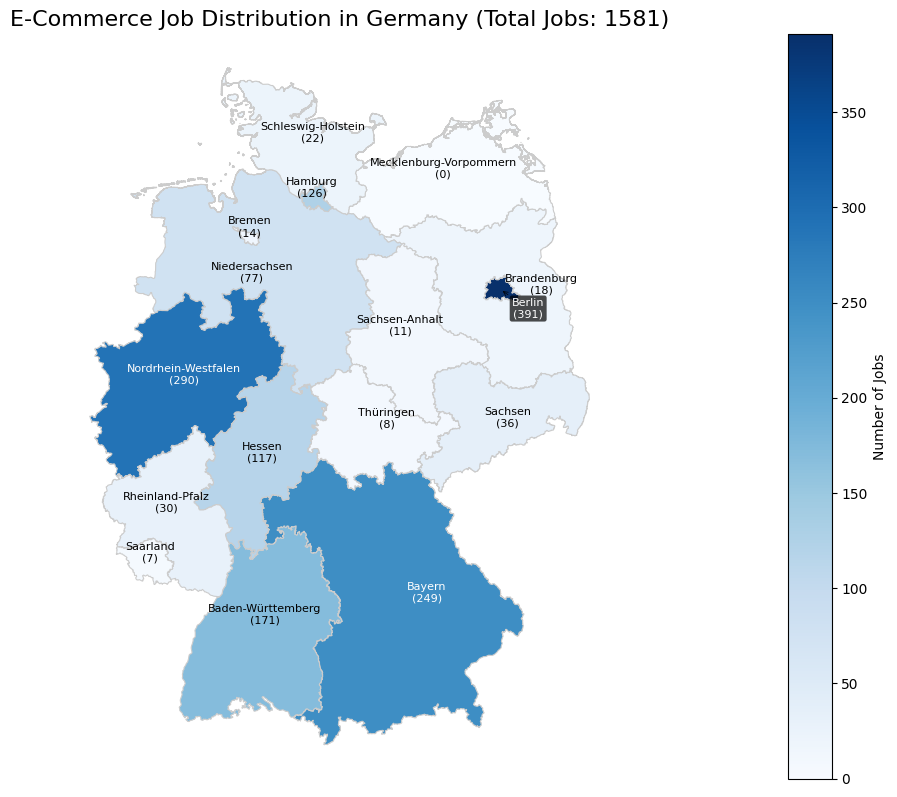

In [8]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

# --- Step 1: Load and prepare data ---

print("Loading 'E_Commers_jobs_done.json'...")
df = pd.read_json('E_Commers_jobs_done.json')

total_jobs = len(df)
jobs_per_region = df['region'].value_counts().reset_index()
jobs_per_region.columns = ['region_name', 'job_count']

print("Job data has been aggregated:")
print(jobs_per_region.head())

# --- Step 2: Load the map (GeoJSON) ---

url_geojson = 'https://raw.githubusercontent.com/isellsoap/deutschlandGeoJSON/main/2_bundeslaender/1_sehr_hoch.geo.json'
print(f"Downloading region map from: {url_geojson}")
gdf_lander = gpd.read_file(url_geojson)

# --- Step 3: Name matching ---
corectii_nume = {
    "North Rhine-Westphalia": "Nordrhein-Westfalen",
    "Bavaria": "Bayern",
    "Hesse": "Hessen",
    "Lower Saxony": "Niedersachsen",
    "Rhineland-Palatinate": "Rheinland-Pfalz",
    "Baden-Württemberg": "Baden-Württemberg",
    "Saxony": "Sachsen",
    "Thuringia": "Thüringen",
    "Saxony-Anhalt": "Sachsen-Anhalt",
    "Mecklenburg-Vorpommern": "Mecklenburg-Vorpommern",
    "Schleswig-Holstein": "Schleswig-Holstein",
    "Brandenburg": "Brandenburg",
    "Bremen": "Bremen",
    "Hamburg": "Hamburg",
    "Saarland": "Saarland",
    "Berlin": "Berlin"
}

print("Correcting region names for matching...")
jobs_per_region['region_name_corectat'] = jobs_per_region['region_name'].map(corectii_nume)
jobs_per_region['region_name_corectat'] = jobs_per_region['region_name_corectat'].fillna(jobs_per_region['region_name'])

# --- Step 4: Merge the data ---
print("Merging job data with the map...")
merged_gdf = gdf_lander.merge(
    jobs_per_region,
    left_on='name',
    right_on='region_name_corectat',
    how='left'
)
merged_gdf['job_count'] = merged_gdf['job_count'].fillna(0)

# --- Step 5: Create the plot ---
print("Generating the map...")

fig, ax = plt.subplots(1, 1, figsize=(12, 12))
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)

vmin = merged_gdf['job_count'].min()
vmax = merged_gdf['job_count'].max()

merged_gdf.plot(
    column='job_count',
    cmap='Blues',
    linewidth=0.8,
    ax=ax,
    edgecolor='0.8',
    legend=True,
    cax=cax,
    legend_kwds={'label': "Number of Jobs"}
)

# --- Dynamic Text Labels and Special Handling for Berlin ---
print("Adding dynamic text labels...")

# Custom position ONLY for Berlin
custom_text_positions = {
    "Berlin": {
        "xytext": (20, -20), # Offset text position
        "arrowprops": dict(facecolor='black', arrowstyle="->", lw=0.5),
        # NEW: Dark background box for white text
        "bbox": dict(boxstyle="round,pad=0.2", fc="black", ec="none", alpha=0.7)
    }
}

for idx, row in merged_gdf.iterrows():
    region_name = row['name']
    job_count = int(row['job_count'])
    
    label_text = f"{region_name}\n({job_count})"
    xy_coords = row.geometry.representative_point().coords[0]
    
    # Dynamic text color for contrast
    text_color = 'white' if job_count > (vmax * 0.5) else 'black'
    
    # --- NEW LOGIC ---
    if region_name == "Berlin":
        # Apply special rules for Berlin
        ax.annotate(
            text=label_text,
            xy=xy_coords,
            xytext=custom_text_positions[region_name]["xytext"],
            textcoords="offset points",
            arrowprops=custom_text_positions[region_name]["arrowprops"],
            ha='center',
            fontsize=8,
            color=text_color, # Will be 'white' based on dynamic logic
            bbox=custom_text_positions[region_name]["bbox"]
        )
    else:
        # Apply standard centered text for ALL other regions
        ax.annotate(
            text=label_text,
            xy=xy_coords,
            ha='center',
            fontsize=8,
            color=text_color
        )

# --- Final Cleanup ---
ax.set_axis_off()
ax.set_title(
    f'E-Commerce Job Distribution in Germany (Total Jobs: {total_jobs})',
    fontdict={'fontsize': '16', 'fontweight' : '3'}
)

# Save the map
plt.savefig("harta_choropleth_regiuni_final.png", dpi=300, bbox_inches='tight')
print("\nSuccess! Map saved as 'harta_choropleth_regiuni_final.png'")

# Show the map
plt.show()

Analysis:
This Choropleth map visualizes the geographical distribution of e-commerce job postings across Germany's 16 federal states (Länder). Each state is shaded based on the total number of available jobs, with darker shades representing a higher concentration of opportunities.

This visualization answers key questions about the market landscape:

Where are the main e-commerce job hubs?

The map immediately identifies the primary economic powerhouses for e-commerce, showing that North Rhine-Westphalia (NRW), Bavaria (Bayern), and Baden-Württemberg are the top regions.

Is the job market concentrated or evenly distributed?

It clearly shows an uneven distribution. A vast majority of jobs are concentrated in the western and southern states, while the eastern states (with the notable exception of Berlin) have significantly fewer postings.

What is the role of city-states?

Despite their small size, Berlin and Hamburg appear as significant, dense hotspots, highlighting their importance as major urban centers for the digital economy, independent of the larger surrounding states.

Where are the "cold spots" or potential areas for growth?

States like Mecklenburg-Vorpommern or Sachsen-Anhalt show very low activity, indicating a lack of industry presence or potentially an untapped market.

## 1.2 Bubble Map (by Cities)

Loading 'E_Commers_jobs_done.json'...
Aggregated data. Plotting Top 100 cities.
Initializing geocoding service (Nominatim/OpenStreetMap)...
Starting geocoding for top cities (this may take 2-3 minutes)...
  Found: Berlin -> (52.5173885, 13.3951309)
  Found: Hamburg -> (53.550341, 10.000654)
  Found: Munich -> (48.1371079, 11.5753822)
  Found: Cologne -> (50.938361, 6.959974)
  Found: Düsseldorf -> (51.2254018, 6.7763137)
  Found: Frankfurt -> (50.1106444, 8.6820917)
  Found: Stuttgart -> (48.7784485, 9.1800132)
  Found: Frankfurt am Main -> (50.1106444, 8.6820917)
  Found: Leipzig -> (51.3406321, 12.3747329)
  Found: Göttingen -> (51.5328328, 9.9351811)
  Found: Bremen -> (53.0758196, 8.8071646)
  Found: Münster -> (51.9625101, 7.6251879)
  Found: Dresden -> (51.0493286, 13.7381437)
  Found: Dortmund -> (51.5142273, 7.4652789)
  Found: Karlsruhe -> (49.0068705, 8.4034195)
  Found: Nuremberg -> (49.453872, 11.077298)
  Found: Würzburg -> (49.7933723, 9.9309779)
  Found: Freiburg -> (47.

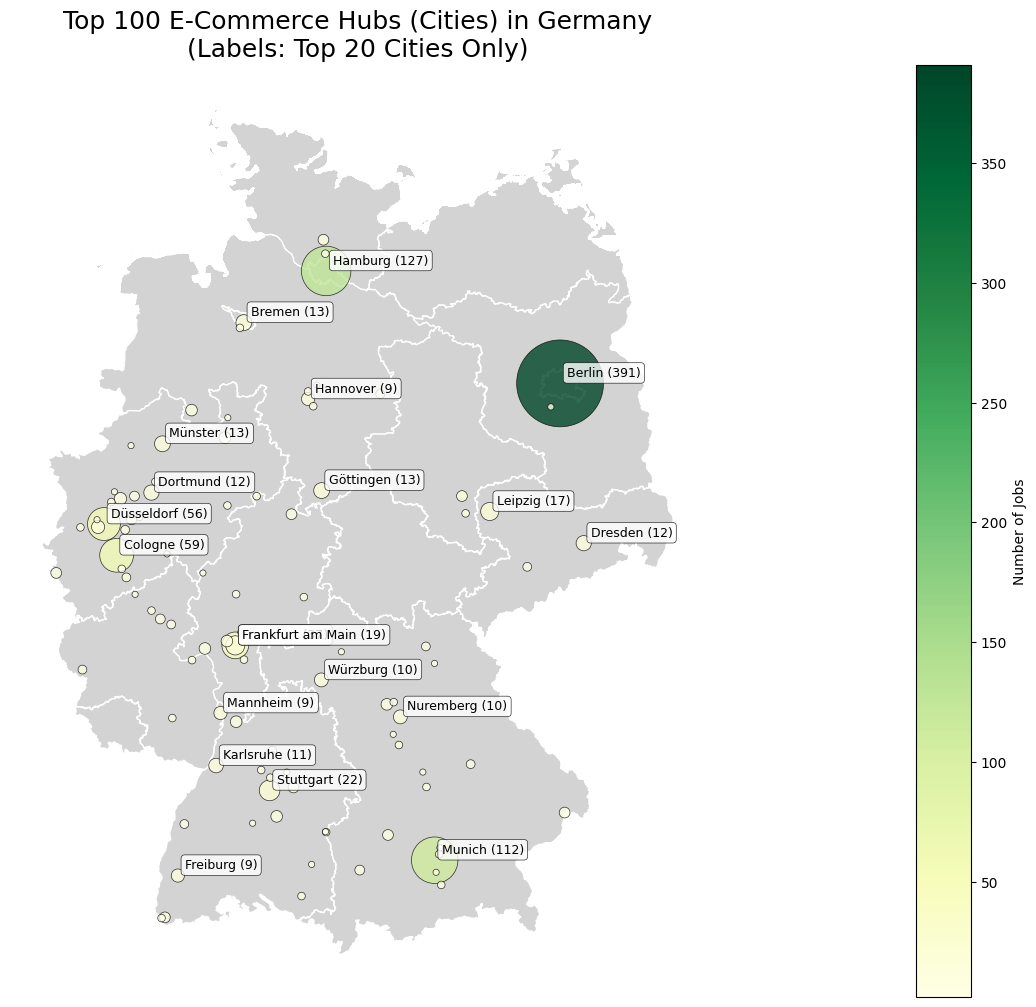

In [14]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
import time

# --- Step 1: Load and aggregate data ---
print("Loading 'E_Commers_jobs_done.json'...")
df = pd.read_json('E_Commers_jobs_done.json')
jobs_per_city = df['city'].value_counts().reset_index()
jobs_per_city.columns = ['city_name', 'job_count']

# --- MODIFICATION HERE ---
# Plot Top 100 cities instead of Top 50 for more context
top_cities_to_plot = jobs_per_city.head(100).copy() 
# -------------------------

print(f"Aggregated data. Plotting Top {len(top_cities_to_plot)} cities.")

# --- Step 2: Geocoding (Getting coordinates) ---
print("Initializing geocoding service (Nominatim/OpenStreetMap)...")
# Always use a unique, descriptive user_agent
geolocator = Nominatim(user_agent="my-ecommerce-portfolio-v4-top100") 
geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1)

def get_coords(city_name):
    query = f"{city_name}, Germany"
    try:
        location = geocode(query)
        if location:
            print(f"  Found: {city_name} -> ({location.latitude}, {location.longitude})")
            return location.latitude, location.longitude
    except Exception as e:
        print(f"  Geocoding error for {city_name}: {e}")
    print(f"  NOT FOUND: {city_name}")
    return None, None

print("Starting geocoding for top cities (this may take 2-3 minutes)...")
coords = top_cities_to_plot['city_name'].apply(get_coords)
top_cities_to_plot['latitude'] = [c[0] for c in coords]
top_cities_to_plot['longitude'] = [c[1] for c in coords]
top_cities_to_plot = top_cities_to_plot.dropna(subset=['latitude', 'longitude'])
print("Geocoding finished.")

# --- Step 3: Convert to GeoDataFrame ---
gdf_cities = gpd.GeoDataFrame(
    top_cities_to_plot,
    geometry=gpd.points_from_xy(top_cities_to_plot.longitude, top_cities_to_plot.latitude),
    crs="EPSG:4326"
)

# --- Step 4: Load base map ---
url_geojson = 'https://raw.githubusercontent.com/isellsoap/deutschlandGeoJSON/main/2_bundeslaender/1_sehr_hoch.geo.json'
gdf_lander = gpd.read_file(url_geojson)

# --- Step 5: Create the plot ---
print("Generating bubble map (Plot Top 100, Label Top 20)...")
fig, ax = plt.subplots(1, 1, figsize=(15, 15))
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)
gdf_lander.plot(ax=ax, color='lightgray', edgecolor='white')

# Plot bubbles with yellow-green colormap and black outlines
gdf_cities.plot(
    ax=ax,
    markersize=gdf_cities['job_count'] * 10,
    column='job_count',
    cmap='YlGn',
    legend=True,
    cax=cax,
    legend_kwds={'label': "Number of Jobs"},
    alpha=0.8,
    edgecolor="black", # Outline to make small bubbles visible
    linewidth=0.5
)

# --- LABELING LOGIC (STAYS THE SAME) ---
# We still only want to label the Top 20
top_20_to_label = gdf_cities.nlargest(20, 'job_count')

# Loop through ONLY the Top 20
for idx, row in top_20_to_label.iterrows():
    ax.annotate(
        f"{row['city_name']} ({int(row['job_count'])})",
        xy=(row.geometry.x, row.geometry.y),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", lw=0.5, alpha=0.8)
    )

# --- Final Cleanup ---
ax.set_axis_off()
ax.set_title(
    'Top 100 E-Commerce Hubs (Cities) in Germany\n(Labels: Top 20 Cities Only)',
    fontdict={'fontsize': '18', 'fontweight' : '3'}
)

plt.savefig("harta_orase_top100.png", dpi=300, bbox_inches='tight')
print("\nSuccess! Map saved as 'harta_orase_top100.png'")
plt.show()

Analysis:
This Proportional Symbol Map (or Bubble Map) pinpoints the specific cities that act as the epicenters for e-commerce employment. The size and color intensity of each bubble represent the total number of job postings. The Top 100 cities are plotted to show the overall landscape, while the Top 20 are labeled for clarity.

This visualization answers several key questions:

What are the dominant city hubs?

The map overwhelmingly highlights Berlin as the single largest, most dominant hub for e-commerce jobs, with a count (391) significantly larger than any other city.

What are the secondary and tertiary hubs?

Hamburg (127) and Munich (112) clearly form the second tier of major employment centers. Following them, a third tier of important cities includes Cologne (59) and Düsseldorf (56), both located in North Rhine-Westphalia.

How does this view complement the regional map?

This city-level view provides crucial context. It confirms that while North Rhine-Westphalia (NRW) is a top region overall, its job market is distributed across multiple large cities (Cologne, Düsseldorf, Dortmund, etc.). In contrast, the job markets in Berlin and Hamburg are highly concentrated within the cities themselves.

Conclusion:

The analysis shows that e-commerce opportunities are not just regionally concentrated but are overwhelmingly centered within Germany's largest metropolitan areas ("Big 5" cities), with Berlin leading the market by a substantial margin

# 2. Skills analysis

## 2.1 Horizontal Bar Chart

Loading data from E_Commers_jobs_done.json...
Loaded 1581 job postings.
Analyzing skills... (exploding lists and counting)

--- Top 25 Skills ---
                    Skill  Count
0               Marketing   1005
1              E-Commerce    895
2              Management    608
3                      IT    389
4                   Sales    380
5                     SEO    372
6                  German    356
7                 English    334
8               Analytics    333
9                    KPIs    319
10            Development    294
11                 Design    275
12              Instagram    267
13      Digital Marketing    260
14               Training    217
15       Google Analytics    217
16              Reporting    207
17             Google Ads    206
18                 Amazon    193
19             Innovation    192
20       Online Marketing    182
21                    CRM    172
22                  Excel    168
23                     AI    160
24  Performance Marketing    

C:\Users\iurie\AppData\Local\Temp\ipykernel_24408\2372717802.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


Success! Chart saved as 'top_skills_barchart.png'


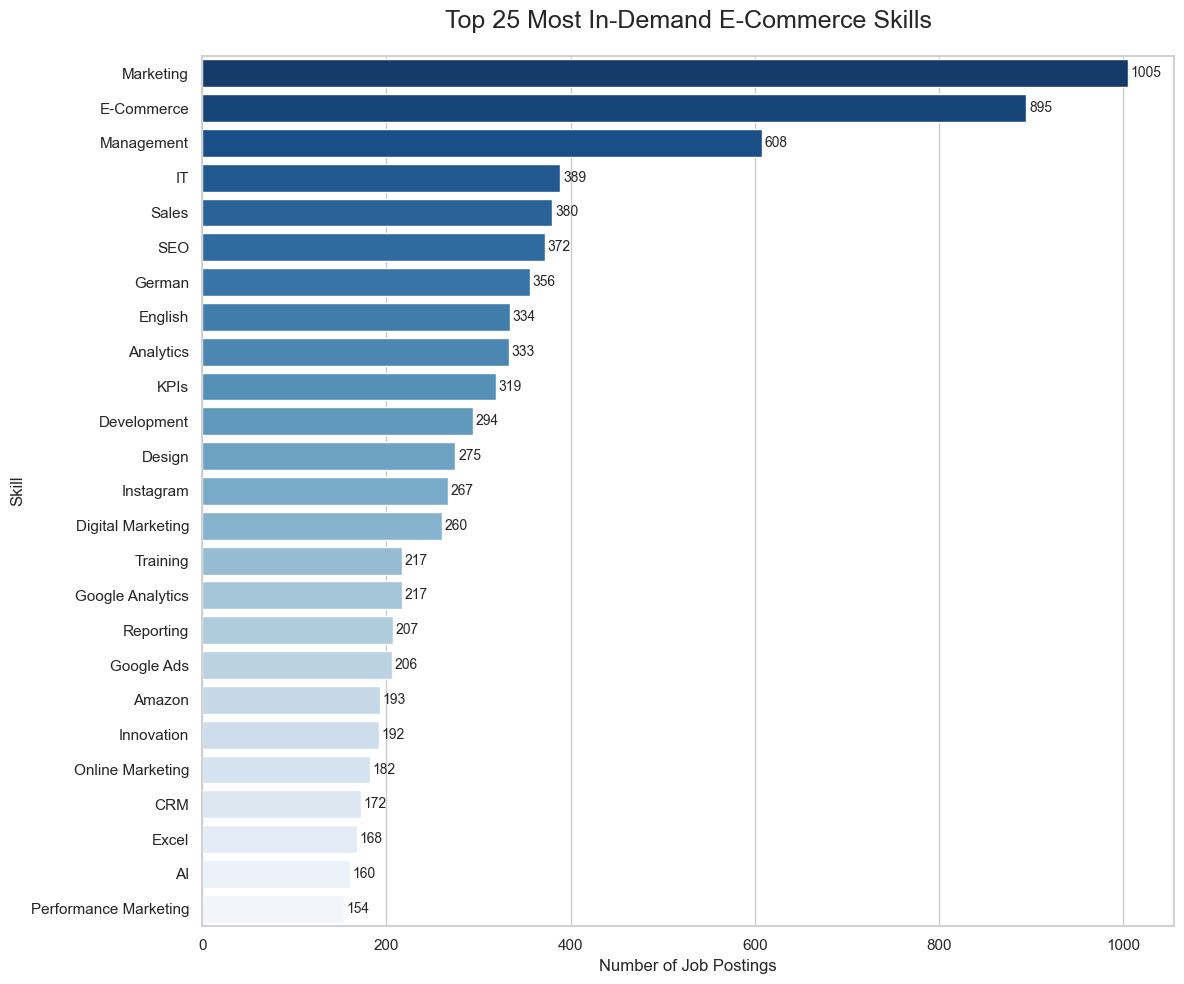

In [71]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- Step 1: Load Data ---
FILE_NAME = 'E_Commers_jobs_done.json'
TOP_N = 25 # How many top skills to show

print(f"Loading data from {FILE_NAME}...")
try:
    df = pd.read_json(FILE_NAME)
except FileNotFoundError:
    print(f"Error: {FILE_NAME} not found.")
    exit()
except Exception as e:
    print(f"Error loading JSON: {e}")
    exit()

print(f"Loaded {len(df)} job postings.")

# --- Step 2: Process and Count Skills ---
# 'explode' is a powerful pandas function.
# It takes a list-like column and "unpacks" it,
# creating a new row for each item in the list.
# 
# Before:
# Job 1 | ["E-Commerce", "SEO"]
#
# After:
# Job 1 | "E-Commerce"
# Job 1 | "SEO"

print("Analyzing skills... (exploding lists and counting)")
# Explode the 'Skills' column
skills_series = df.explode('Skills')

# Drop any 'None' or 'NaN' values that might have resulted
skills_cleaned = skills_series.dropna(subset=['Skills'])

# Count the frequency of each skill
skill_counts = skills_cleaned['Skills'].value_counts()

# --- Step 3: Prepare Data for Plotting ---
# Select the Top N skills and format as a DataFrame
top_skills_df = skill_counts.head(TOP_N).reset_index()
top_skills_df.columns = ['Skill', 'Count']

print(f"\n--- Top {TOP_N} Skills ---")
print(top_skills_df)

# --- Step 4: Create the Horizontal Bar Chart ---
print("\nGenerating plot...")
sns.set_theme(style="whitegrid") # Set a nice theme

# Create the figure
plt.figure(figsize=(12, 10)) # (width, height) in inches

# Create the bar plot using seaborn
# We use a reversed palette (e.g., "Blues_r") so the
# top skill (highest count) gets the darkest color.
ax = sns.barplot(
    x='Count', 
    y='Skill', 
    data=top_skills_df, 
    palette="Blues_r" # You can change this to "Greens_r", "Reds_r" etc.
)

# --- Step 5: Customize and Save Plot ---
# Set titles and labels
ax.set_title(f'Top {TOP_N} Most In-Demand E-Commerce Skills', fontsize=18, pad=20)
ax.set_xlabel('Number of Job Postings', fontsize=12)
ax.set_ylabel('Skill', fontsize=12)

# --- Add Data Labels (the count) on the bars ---
# This is a great touch for a portfolio
for p in ax.patches:
    width = p.get_width() # Get the width (the count) of the bar
    ax.annotate(
        f'{int(width)}', # The text to display
        (width + 3, p.get_y() + p.get_height() / 2), # Position (x, y)
        ha='left',   # Horizontal alignment
        va='center', # Vertical alignment
        fontsize=10
    )

# Adjust layout to prevent labels from being cut off
plt.tight_layout()

# Save the figure
output_image = "top_skills_barchart.png"
plt.savefig(output_image, dpi=300, bbox_inches='tight')
print(f"Success! Chart saved as '{output_image}'")

# Show the plot
plt.show()

Analysis:
This horizontal bar chart ranks the top 25 most in-demand skills for e-commerce positions based on their frequency in job postings. The chart clearly illustrates the multi-disciplinary nature of e-commerce roles, which blend business management, technical knowledge, and marketing expertise.

This visualization answers key questions about the required competencies:

What are the dominant "pillar" skills?

Marketing (1005) and E-Commerce (895) are the two most critical skills by a significant margin, forming the foundational knowledge required for nearly all roles. Management (608) follows closely, indicating that many e-commerce roles involve leadership, project, or process management.

What are the core "hard skills"?

A strong technical and analytical component is evident. IT (389) is a major requirement, followed by specific digital marketing skills like SEO (372), Analytics (333), and KPIs (319). This highlights the need for professionals who can not only manage a platform but also analyze and optimize its performance.

What are the key "soft skills"?

Language skills are crucial. German (356) and English (334) are both ranked very highly, reflecting the international and local nature of e-commerce in Germany.

What specific tools and platforms are most mentioned?

The chart shows a clear demand for platform-specific knowledge. Instagram (267) leads as a key social media channel, followed by the Google stack (Google Analytics, Google Ads) and Amazon (193), confirming the importance of marketplace management.

Conclusion:

The ideal e-commerce candidate is not just a marketer or a salesperson. They are a "T-shaped" professional with deep expertise in Marketing and E-Commerce, supported by a strong foundation in Management, IT/Analytics, and key platform knowledge (like Google, Amazon, and Instagram).

## 2.2 Top N Skills vs. Top N Regions Heatmap

Loading data from E_Commers_jobs_done.json...
Loaded 1581 job postings.

--- Top 5 Regions ---
Index(['Berlin', 'North Rhine-Westphalia', 'Bavaria', 'Baden-Württemberg',
       'Hamburg'],
      dtype='object', name='region')

--- Top 15 Skills ---
Index(['Marketing', 'E-Commerce', 'Management', 'IT', 'Sales', 'SEO', 'German',
       'English', 'Analytics', 'KPIs', 'Development', 'Design', 'Instagram',
       'Digital Marketing', 'Training'],
      dtype='object', name='Skills')

Creating cross-tabulation matrix...

--- Heatmap Matrix ---
Skills                  Marketing  E-Commerce  Management  IT  Sales  SEO  \
region                                                                      
Berlin                        242         208         148  78     95   58   
North Rhine-Westphalia        195         163         100  61     73   99   
Bavaria                       178         139         101  46     53   73   
Baden-Württemberg             109         105          74  51     47  

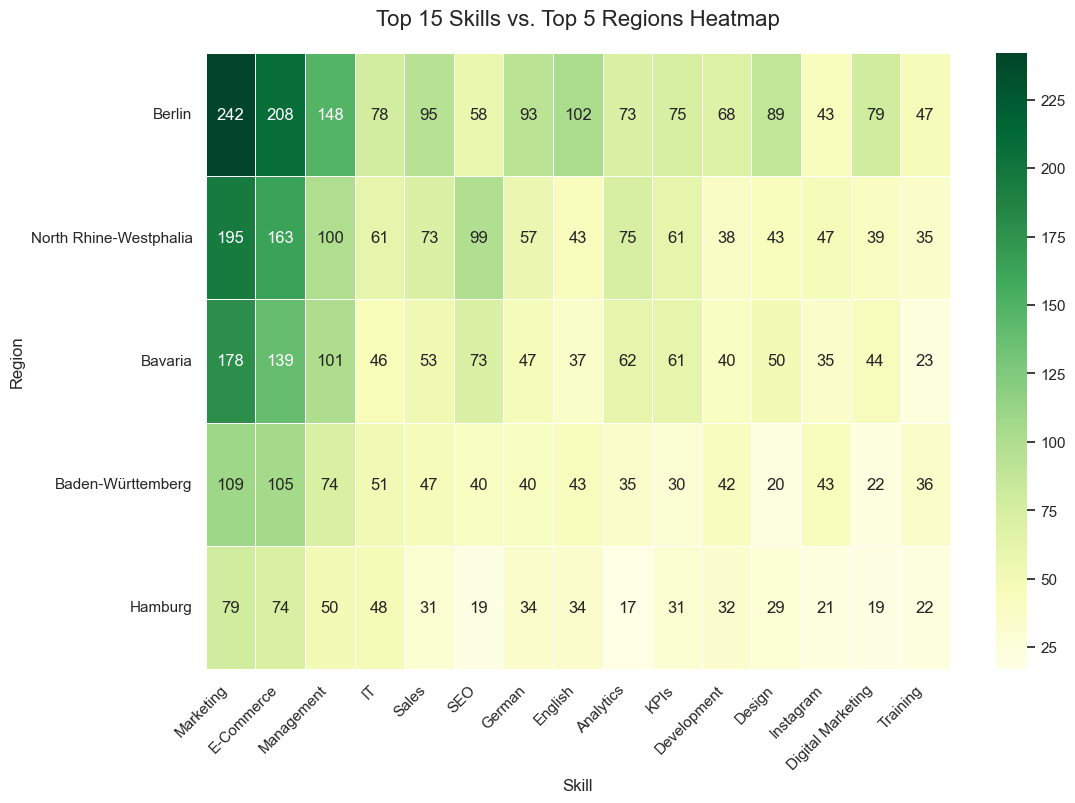

In [72]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- Step 1: Load Data ---
FILE_NAME = 'E_Commers_jobs_done.json'
TOP_N_REGIONS = 5
TOP_N_SKILLS = 15

print(f"Loading data from {FILE_NAME}...")
try:
    df = pd.read_json(FILE_NAME)
except FileNotFoundError:
    print(f"Error: {FILE_NAME} not found.")
    exit()
except Exception as e:
    print(f"Error loading JSON: {e}")
    exit()

print(f"Loaded {len(df)} job postings.")

# --- Step 2: Find Top 5 Regions ---
# Clean region data first
df['region'] = df['region'].fillna('Not specified')
top_regions = df['region'].value_counts().head(TOP_N_REGIONS).index
print(f"\n--- Top {TOP_N_REGIONS} Regions ---")
print(top_regions)

# --- Step 3: Find Top 10 Skills ---
# Explode the 'Skills' column to count all skills
skills_series = df.explode('Skills')
skills_cleaned = skills_series.dropna(subset=['Skills'])
top_skills = skills_cleaned['Skills'].value_counts().head(TOP_N_SKILLS).index
print(f"\n--- Top {TOP_N_SKILLS} Skills ---")
print(top_skills)

# --- Step 4: Filter and Create the Matrix ---

# Filter the main DataFrame to include ONLY the top regions
df_filtered_regions = df[df['region'].isin(top_regions)]

# Explode the skills column from this filtered DataFrame
df_exploded = df_filtered_regions.explode('Skills')

# Filter this exploded data to include ONLY the top skills
df_final_filtered = df_exploded[df_exploded['Skills'].isin(top_skills)]

print("\nCreating cross-tabulation matrix...")
# Create the crosstab (matrix)
# This counts the co-occurrence of each top skill in each top region
try:
    matrix = pd.crosstab(df_final_filtered['region'], df_final_filtered['Skills'])
    
    # Re-order the matrix to match the top-to-bottom order (optional but nice)
    matrix = matrix.loc[top_regions] # Order rows
    matrix = matrix[top_skills]      # Order columns
    
except KeyError:
    print("\nError: One of the top regions or skills was not found after filtering.")
    print("This can happen if a skill/region is 'Not specified' and filtered out.")
    exit()

print("\n--- Heatmap Matrix ---")
print(matrix)

# --- Step 5: Plot the Heatmap ---
print("\nGenerating heatmap...")
plt.figure(figsize=(12, 8)) # width, height

# Create the heatmap
ax = sns.heatmap(
    matrix, 
    annot=True,     # Show the numbers in each cell
    fmt='d',        # Format the numbers as integers (e.g., "150" not "150.0")
    cmap='YlGn',    # Use the Yellow-Green colormap
    linewidths=.5   # Add thin lines between cells
)

# Customize plot
ax.set_title(f'Top {TOP_N_SKILLS} Skills vs. Top {TOP_N_REGIONS} Regions Heatmap', fontsize=16, pad=20)
ax.set_xlabel('Skill', fontsize=12)
ax.set_ylabel('Region', fontsize=12)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

# Save the figure
output_image = "heatmap_skills_regions.png"
plt.savefig(output_image, dpi=300, bbox_inches='tight')
print(f"Success! Heatmap saved as '{output_image}'")

plt.show()

Analysis:
This heatmap provides a powerful cross-analysis, showing the absolute demand for the Top 15 skills within the Top 5 job regions. The color intensity represents the number of job postings at the intersection of a specific skill and a specific region.

This visualization answers complex questions about the job market's structure:

Are core skills universal?

Yes. The chart clearly shows that the "big three" skills—Marketing, E-Commerce, and Management—are the most in-demand skills in every single one of the top 5 regions. This confirms they are the universal foundation for the e-commerce sector, regardless of location.

Is skill demand concentrated?

Yes. The dark green band at the top (Berlin, North Rhine-Westphalia, Bavaria) shows that these top regions have the highest demand across all skill categories. The demand for specific skills (like IT or SEO) scales directly with the overall size of the region's job market.

Are there any regional specialties?

While the core skills are consistent, we can spot subtle specialties. Berlin shows a significantly high demand not only for Marketing (242) and E-Commerce (208) but also for English (102), reinforcing its role as a major international and English-speaking tech hub.

North Rhine-Westphalia (NRW) shows a very robust and balanced demand across the board, particularly in Management (100) and IT (61), reflecting its large, diversified industrial and commercial base.

Conclusion:

This heatmap demonstrates that the e-commerce job market is highly consistent. The primary difference between regions is not the type of skills required, but the volume of demand. The top skills in Berlin are largely the same as in Hamburg; there are just far more jobs, and thus a greater absolute need for every skill, in Berlin.

## 2.3 Word Cloud

Loading data from E_Commers_jobs_done.json...
Loaded 1581 job postings.
Counted 435 unique skills.
Generating Word Cloud with frequency-based colors...
Saving plot...
Success! Word Cloud saved as 'skills_word_cloud_YlGn.png'


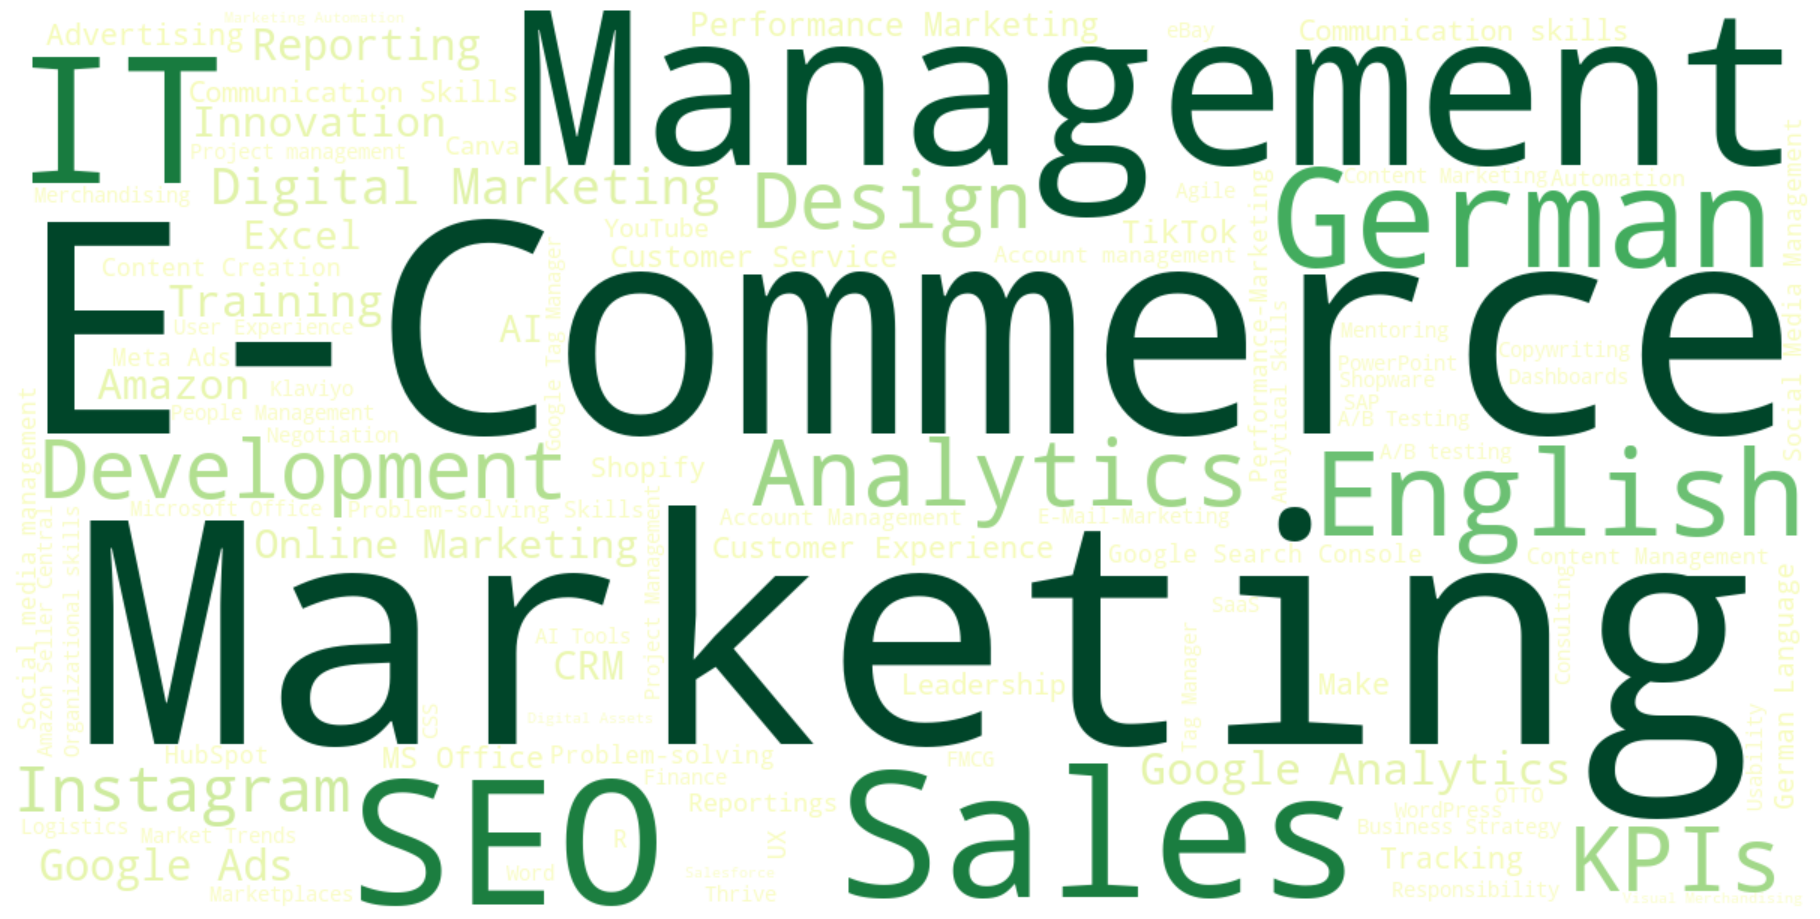

In [26]:
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors # To normalize colors

# --- Step 1: Load Data ---
FILE_NAME = 'E_Commers_jobs_done.json'

print(f"Loading data from {FILE_NAME}...")
try:
    df = pd.read_json(FILE_NAME)
except FileNotFoundError:
    print(f"Error: {FILE_NAME} not found.")
    exit()
except Exception as e:
    print(f"Error loading JSON: {e}")
    exit()

print(f"Loaded {len(df)} job postings.")

# --- Step 2: Process and Count Skills ---
skills_series = df.explode('Skills')
skills_cleaned = skills_series.dropna(subset=['Skills'])
skill_counts = skills_cleaned['Skills'].value_counts()

if skill_counts.empty:
    print("No skills found in the data. Exiting.")
    exit()

skills_dict = skill_counts.to_dict()

print(f"Counted {len(skills_dict)} unique skills.")

# --- Step 3: Generate the Word Cloud with Custom Colors ---
print("Generating Word Cloud with frequency-based colors...")

# We use 'YlGn' (Yellow-Green) just like in the map.
# Small words (low freq) will be Yellow.
# Large words (high freq) will be Dark Green.
colormap_name = 'YlGn' 

# --- MODIFICATION HERE (Fix for DeprecationWarning) ---
# Create a colormap object
# Old way: cmap = plt.cm.get_cmap(colormap_name)
cmap = plt.get_cmap(colormap_name) # New, recommended way
# -----------------------------------------------------

# --- Custom color function ---
def color_func(word, font_size, position, orientation, random_state=None, **kwargs):
    
    max_font_size = 150 # Estimate a typical max font size
    
    # Normalize font_size to be between 0 and 1
    normalized_size = min(1.0, max(0.0, font_size / max_font_size))
    
    # Get color from colormap
    rgba_color = cmap(normalized_size)
    
    # Convert RGBA to RGB tuple (0-255) for WordCloud
    return 'rgb({},{},{})'.format(
        int(rgba_color[0]*255), 
        int(rgba_color[1]*255), 
        int(rgba_color[2]*255)
    )

# Initialize the WordCloud object
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    colormap=colormap_name, 
    max_words=100,
    contour_width=1,
    contour_color='gray',
    collocations=False,
    random_state=42,
    color_func=color_func # Apply our custom color function
)

# Generate the cloud from our skill frequencies
wordcloud.generate_from_frequencies(skills_dict)

# --- Step 4: Display and Save the Plot ---
print("Saving plot...")
plt.figure(figsize=(18, 9))
plt.imshow(
    wordcloud, 
    interpolation='bilinear'
)
plt.axis('off')
plt.tight_layout(pad=0)

output_image = "skills_word_cloud_YlGn.png"
plt.savefig(output_image, dpi=300, bbox_inches='tight')
print(f"Success! Word Cloud saved as '{output_image}'")

plt.show()

Analysis:
This Word Cloud provides a dynamic visual summary of the entire skill landscape for e-commerce jobs. The size and color intensity of each word are directly proportional to its frequency in the dataset—larger, darker words are the most in-demand.

This visualization confirms the findings from the bar chart and provides immediate, at-a-glance insights:

What are the dominant skills?

The cloud is overwhelmingly dominated by Marketing, E-Commerce, and Management. Their massive size clearly establishes them as the "Big 3" pillars of the entire job market.

What forms the core of the market?

A strong secondary group of skills is clearly visible, forming the core operational requirements. This includes Sales, IT, SEO, German, English, Analytics, and KPIs.

What are the specific, "niche" skills?

Surrounding the main terms, we can see a rich ecosystem of specific tools and competencies. Words like Instagram, Google Ads, Google Analytics, Shopify, Amazon, and CRM are visible, indicating the specific platforms and sub-specialties employers are hiring for.

Conclusion:

This visual immediately communicates the profile of an ideal e-commerce candidate: a professional with a massive foundation in Marketing and E-Commerce, strong capabilities in Management and Sales, and a technical understanding of IT and Analytics.

# 3. Category Analysis (Distribution)

## 3.1 Job Distribution by Experience Level

### 3.1.1 Job Distribution by Experience Level

Loading data from E_Commers_jobs_done.json...
Loaded 1581 job postings.
Analyzing experience levels...
Filtered out: ['N/A', 'Not specified', 'Not Applicable']

--- Experience Level Counts (Filtered) ---
   Experience Level  Count
0       Entry level    593
1  Mid-Senior level    566
2         Associate    172
4        Internship     49
7          Director     21
8         Executive      6

Generating plot...
Success! Chart saved as 'experience_level_barchart_v4.png'


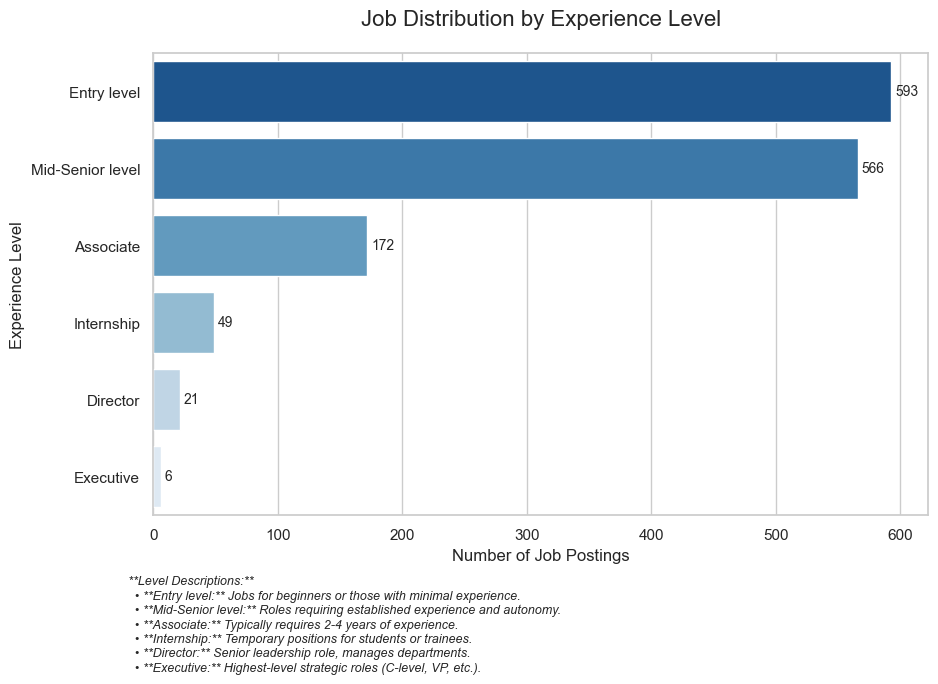

In [30]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- Step 1: Load Data ---
FILE_NAME = 'E_Commers_jobs_done.json'

print(f"Loading data from {FILE_NAME}...")
try:
    df = pd.read_json(FILE_NAME)
except FileNotFoundError:
    print(f"Error: {FILE_NAME} not found.")
    exit()
except Exception as e:
    print(f"Error loading JSON: {e}")
    exit()

print(f"Loaded {len(df)} job postings.")

# --- Step 2: Process and Count Experience Levels ---

# Handle missing or empty values
df['Experience'] = df['Experience'].fillna('Not specified')
df['Experience'] = df['Experience'].replace('', 'Not specified')

print("Analyzing experience levels...")
# Count the frequency
experience_counts = df['Experience'].value_counts()

# --- Step 3: Prepare Data for Plotting ---
# Format as a DataFrame
exp_df = experience_counts.reset_index()
exp_df.columns = ['Experience Level', 'Count']

# Define a list of categories to exclude from the plot
exclude_list = ['N/A', 'Not specified', 'Not Applicable']
exp_df_filtered = exp_df[~exp_df['Experience Level'].isin(exclude_list)].copy()
print(f"Filtered out: {exclude_list}")

print("\n--- Experience Level Counts (Filtered) ---")
print(exp_df_filtered)

# --- Step 4: Create the Horizontal Bar Chart ---
print("\nGenerating plot...")
sns.set_theme(style="whitegrid")

# Create figure
fig, ax = plt.subplots(figsize=(10, 6))

# Fix for seaborn FutureWarning
ax = sns.barplot(
    x='Count', 
    y='Experience Level', 
    data=exp_df_filtered, # Use the filtered data
    palette="Blues_r",
    hue='Experience Level', 
    legend=False          
)

# --- Step 5: Customize and Save Plot ---
ax.set_title('Job Distribution by Experience Level', fontsize=16, pad=20)
ax.set_xlabel('Number of Job Postings', fontsize=12)
ax.set_ylabel('Experience Level', fontsize=12)

# Add Data Labels (the count) on the bars
for p in ax.patches:
    width = p.get_width()
    ax.annotate(
        f'{int(width)}',
        (width + 3, p.get_y() + p.get_height() / 2),
        ha='left',
        va='center',
        fontsize=10
    )

# --- MODIFICATION: Add left-aligned explanation text ---
# Create the explanation string
explanation_string = (
    "**Level Descriptions:**\n"
    "  • **Entry level:** Jobs for beginners or those with minimal experience.\n"
    "  • **Mid-Senior level:** Roles requiring established experience and autonomy.\n"
    "  • **Associate:** Typically requires 2-4 years of experience.\n"
    "  • **Internship:** Temporary positions for students or trainees.\n"
    "  • **Director:** Senior leadership role, manages departments.\n"
    "  • **Executive:** Highest-level strategic roles (C-level, VP, etc.)."
)

# Add the text to the figure, positioned at the bottom-left
# We set x=0.1 (10% from the left) and ha="left"
fig.text(0.1, 0.01, explanation_string, ha="left", va="top", fontsize=9, style='italic', wrap=True)
# -----------------------------------------------------------

# Save the figure
output_image = "experience_level_barchart_v4.png"
# We must use bbox_inches='tight' to ensure the figtext is included
plt.savefig(output_image, dpi=300, bbox_inches='tight')
print(f"Success! Chart saved as '{output_image}'")

plt.show()

Analysis:
This bar chart illustrates the distribution of e-commerce job postings across different experience levels. It provides a clear view of the market's structure and where the demand for talent is concentrated.

This visualization answers key questions about career opportunities:

What is the primary demand?

The market is overwhelmingly dominated by the top two tiers: Entry level (593 jobs) and Mid-Senior level (566 jobs). This dual demand is significant: it shows the industry is rapidly expanding (needing new talent at the "Entry level") while simultaneously maturing (needing experienced "Mid-Senior" professionals to lead).

What does the career path look like?

The chart shows a clear progression. Associate (172 jobs) represents a healthy mid-point between entry-level and senior roles. Internship (49 jobs) provides a clear path into the industry for students.

Where are the leadership roles?

Senior leadership roles are, as expected, much rarer. Director (21 jobs) and Executive (6 jobs) represent the small percentage of top-tier strategic positions.

Conclusion:

The e-commerce job market is extremely robust at both ends of the non-executive spectrum. There is a massive need for both new talent to join the workforce and experienced professionals to manage its growth. The data strongly suggests a "bottom-and-middle-heavy" industry with ample opportunities for entry and mid-career advancement.

### 3.1.2 Top N skils by experience level

Loading data from E_Commers_jobs_done.json...
Loaded 1581 job postings.

Analyzing skills for: Entry level
--- Top 10 Skills for Entry level ---
        Skill  Count
0  E-Commerce    350
1   Marketing    334
2  Management    203
3          IT    187
4       Sales    180
5   Instagram    174
6      German    156
7     English    148
8    Training    146
9         SEO    145

Analyzing skills for: Mid-Senior level
--- Top 10 Skills for Mid-Senior level ---
        Skill  Count
0   Marketing    421
1  E-Commerce    311
2  Management    250
3        KPIs    181
4         SEO    157
5   Analytics    146
6      Design    132
7          IT    127
8   Reporting    121
9       Sales    119

Analyzing skills for: Associate
--- Top 10 Skills for Associate ---
              Skill  Count
0         Marketing    112
1        E-Commerce    105
2        Management     74
3              KPIs     49
4             Sales     40
5               SEO     36
6            Amazon     35
7         Analytics     3

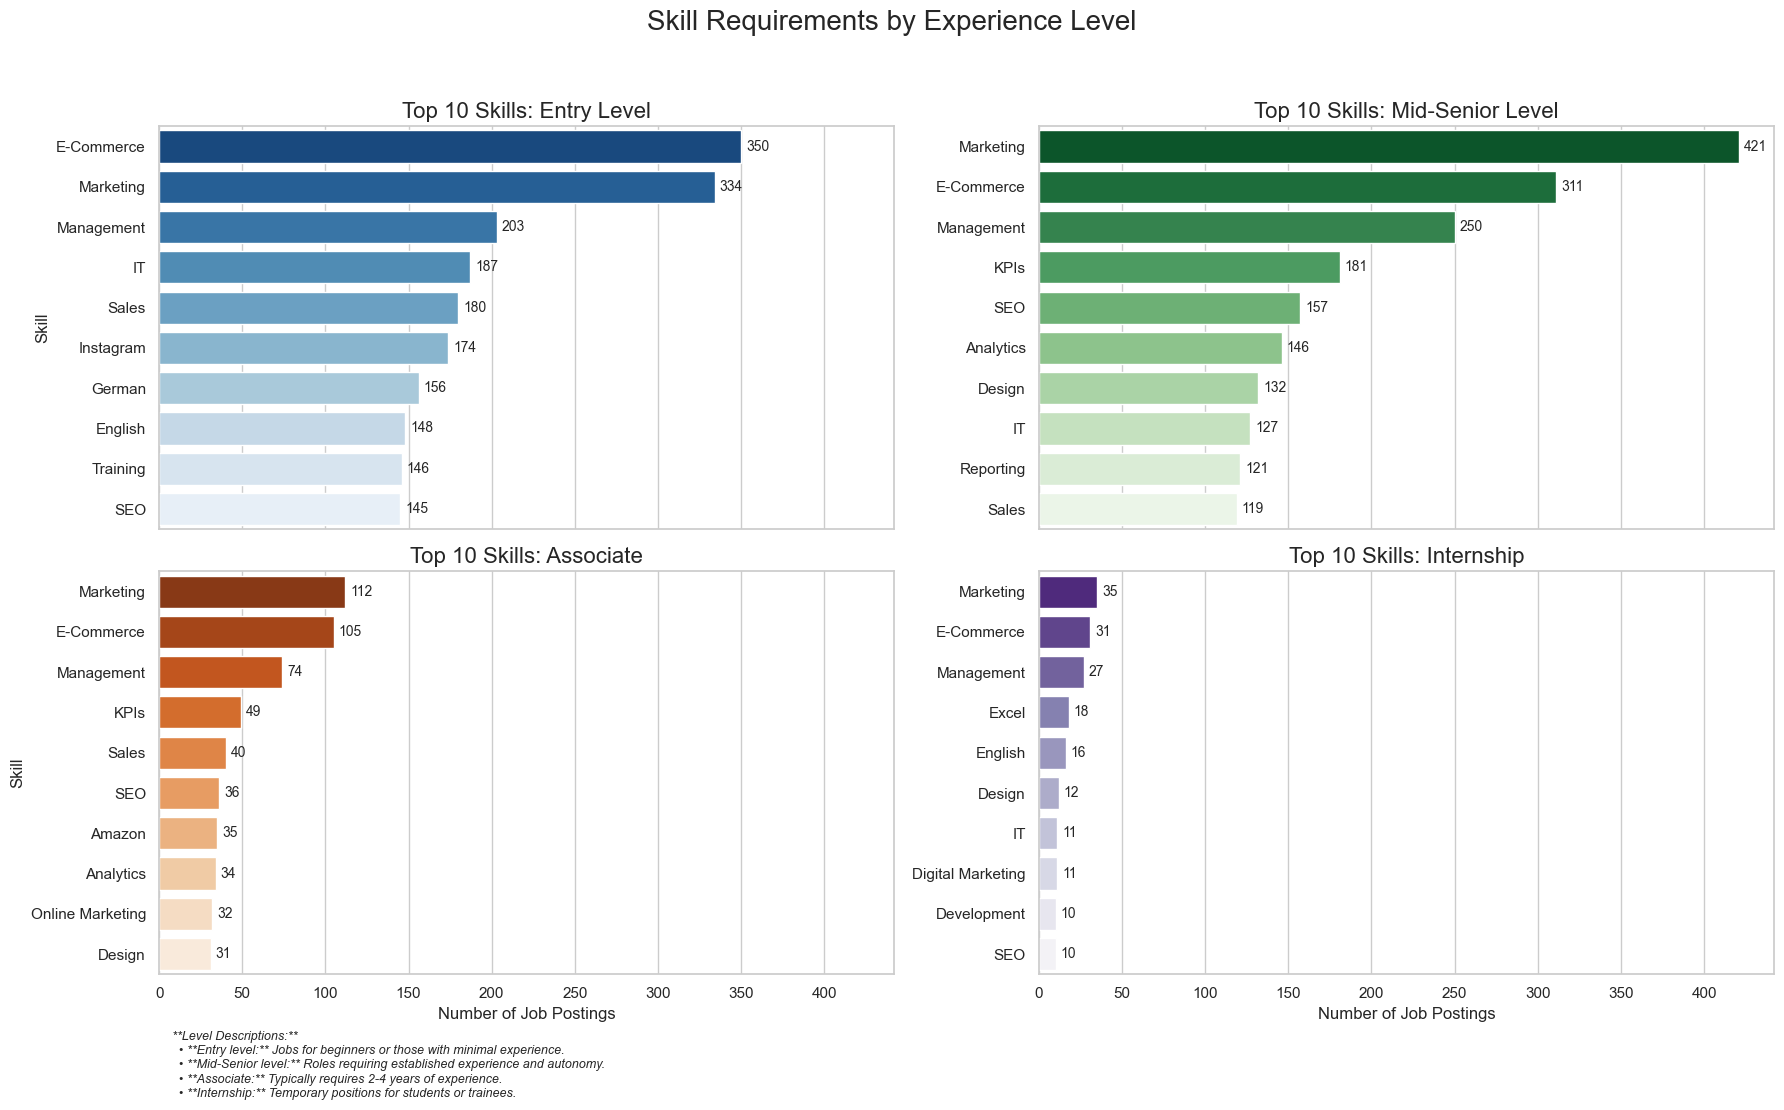

In [76]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- Step 1: Load Data ---
FILE_NAME = 'E_Commers_jobs_done.json'
TOP_N = 10

print(f"Loading data from {FILE_NAME}...")
try:
    df = pd.read_json(FILE_NAME)
except FileNotFoundError:
    print(f"Error: {FILE_NAME} not found.")
    exit()
except Exception as e:
    print(f"Error loading JSON: {e}")
    exit()

print(f"Loaded {len(df)} job postings.")

# --- Step 2: Clean 'Experience' Column ---
df['Experience'] = df['Experience'].fillna('Not specified')
df['Experience'] = df['Experience'].replace('', 'Not specified')
df['Experience'] = df['Experience'].replace('N/A', 'Not specified')

# --- Helper Function for Analysis ---
def get_top_skills(dataframe, level_name, top_n):
    """
    Filters a DataFrame for an experience level,
    explodes skills, and returns a Top N DataFrame.
    """
    print(f"\nAnalyzing skills for: {level_name}")
    
    df_level = dataframe[dataframe['Experience'] == level_name].copy()
    
    if df_level.empty:
        print(f"No jobs found for {level_name}.")
        return pd.DataFrame(columns=['Skill', 'Count'])
        
    skills_series = df_level.explode('Skills')
    skills_cleaned = skills_series.dropna(subset=['Skills'])
    skill_counts = skills_cleaned['Skills'].value_counts()
    
    top_skills_df = skill_counts.head(top_n).reset_index()
    top_skills_df.columns = ['Skill', 'Count']
    
    print(f"--- Top {top_n} Skills for {level_name} ---")
    print(top_skills_df)
    
    return top_skills_df

# --- Step 3: Get Top Skills for all 4 Levels ---
top_skills_entry = get_top_skills(df, 'Entry level', TOP_N)
top_skills_mid = get_top_skills(df, 'Mid-Senior level', TOP_N)
top_skills_assoc = get_top_skills(df, 'Associate', TOP_N)
top_skills_intern = get_top_skills(df, 'Internship', TOP_N)

# --- Step 4: Create the 2x2 Comparison Plot ---
print("\nGenerating 2x2 comparison plot...")
sns.set_theme(style="whitegrid")

# Create a figure with 2x2 subplots
fig, ax = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(18, 10),
    sharex=True # Share the X-axis
)

# --- Helper function to add data labels ---
def add_labels(axis):
    for p in axis.patches:
        width = p.get_width()
        axis.annotate(
            f'{int(width)}', (width + 3, p.get_y() + p.get_height() / 2),
            ha='left', va='center', fontsize=10
        )

# --- Plot 1 (Top-Left): Entry Level ---
if not top_skills_entry.empty:
    sns.barplot(
        x='Count', y='Skill', data=top_skills_entry,
        palette='Blues_r', hue='Skill', legend=False, ax=ax[0, 0]
    )
    ax[0, 0].set_title(f'Top {TOP_N} Skills: Entry Level', fontsize=16)
    ax[0, 0].set_xlabel('')
    ax[0, 0].set_ylabel('Skill', fontsize=12)
    add_labels(ax[0, 0])
else:
    ax[0, 0].set_title('No Data for Entry Level')

# --- Plot 2 (Top-Right): Mid-Senior Level ---
if not top_skills_mid.empty:
    sns.barplot(
        x='Count', y='Skill', data=top_skills_mid,
        palette='Greens_r', hue='Skill', legend=False, ax=ax[0, 1]
    )
    ax[0, 1].set_title(f'Top {TOP_N} Skills: Mid-Senior Level', fontsize=16)
    ax[0, 1].set_xlabel('')
    ax[0, 1].set_ylabel('')
    add_labels(ax[0, 1])
else:
    ax[0, 1].set_title('No Data for Mid-Senior Level')

# --- Plot 3 (Bottom-Left): Associate ---
if not top_skills_assoc.empty:
    sns.barplot(
        x='Count', y='Skill', data=top_skills_assoc,
        palette='Oranges_r', hue='Skill', legend=False, ax=ax[1, 0]
    )
    ax[1, 0].set_title(f'Top {TOP_N} Skills: Associate', fontsize=16)
    ax[1, 0].set_xlabel('Number of Job Postings', fontsize=12)
    ax[1, 0].set_ylabel('Skill', fontsize=12)
    add_labels(ax[1, 0])
else:
    ax[1, 0].set_title('No Data for Associate')

# --- Plot 4 (Bottom-Right): Internship ---
if not top_skills_intern.empty:
    sns.barplot(
        x='Count', y='Skill', data=top_skills_intern,
        palette='Purples_r',
        hue='Skill', legend=False, ax=ax[1, 1]
    )
    ax[1, 1].set_title(f'Top {TOP_N} Skills: Internship', fontsize=16)
    ax[1, 1].set_xlabel('Number of Job Postings', fontsize=12)
    ax[1, 1].set_ylabel('')
    add_labels(ax[1, 1])
else:
    ax[1, 1].set_title('No Data for Internship')

# --- Step 5: Customize and Save ---
fig.suptitle('Skill Requirements by Experience Level', fontsize=20, y=1.03)

# --- MODIFICATION: Add explanation text below chart ---
explanation_string = (
    "**Level Descriptions:**\n"
    "  • **Entry level:** Jobs for beginners or those with minimal experience.\n"
    "  • **Mid-Senior level:** Roles requiring established experience and autonomy.\n"
    "  • **Associate:** Typically requires 2-4 years of experience.\n"
    "  • **Internship:** Temporary positions for students or trainees."
)
# Add the text to the figure, positioned at the bottom-left
fig.text(0.1, 0.01, explanation_string, ha="left", va="top", fontsize=9, style='italic', wrap=True)
# -----------------------------------------------------------

plt.tight_layout()
output_image = "skills_by_experience_2x2_v3.png"
plt.savefig(output_image, dpi=300, bbox_inches='tight')
print(f"Success! Chart saved as '{output_image}'")

plt.show()

Analysis:
This 2x2 grid is a powerful visualization that directly compares the Top 10 most in-demand skills across the four primary experience levels. It perfectly illustrates the evolution of a career in e-commerce, showing how skill requirements shift from foundational knowledge to strategic and analytical expertise.

Entry Level vs. Mid-Senior Level (The Core Story):

Entry Level is defined by foundational and operational skills. The top requirements are the core concepts of E-Commerce (350) and Marketing (334), followed by Management (203) and specific technical/platform skills like IT (187), Sales (180), and Instagram (174). Language skills (German, English) are also crucial for daily operations.

Mid-Senior Level shows a clear shift in priority. While Marketing (421) and E-Commerce (311) remain dominant, the key difference is the emergence of strategic and analytical skills. KPIs (181), SEO (157), and Analytics (146) have replaced operational skills like "Instagram" and "Training" in the top 10. This signals a move from doing tasks to optimizing performance and managing strategy.

The "In-Between" Roles (Associate & Internship):

Associate acts as a perfect bridge. The top skills (Marketing, E-Commerce, Management) mirror the other levels, but its list also emphasizes performance skills like KPIs (49) and SEO (36). It also uniquely features Amazon (35), suggesting "Associate" is a common level for platform specialization.

Internship shows the bare essentials. The top 3 are again Marketing, E-Commerce, and Management, but the list also includes fundamental office skills like Excel (18), which doesn't appear in the other top 10s.

Conclusion (The "T-Shaped" Professional):

This comparison clearly shows the career path. Professionals enter the field with a broad base in Marketing and E-Commerce. As they advance in seniority, they are expected to specialize and add deep analytical skills (Analytics, KPIs, SEO) and broader Management capabilities to their profile.

### 3.1.2 Monthly Job Posting Trend by Experience Level

Loading data from E_Commers_jobs_done.json...
Loaded 1581 job postings.
Converted 1496 rows to datetime objects.
Filtered data to 1380 rows with relevant experience levels.

--- Aggregated Monthly Counts by Experience ---
    Experience      Month  Number of Postings
0    Associate 2025-09-30                  12
1    Associate 2025-10-31                 160
2  Entry level 2025-05-31                   4
3  Entry level 2025-06-30                   7
4  Entry level 2025-07-31                  13

Generating plot...
Success! Chart saved as 'job_trend_multiline_experience_v4.png'


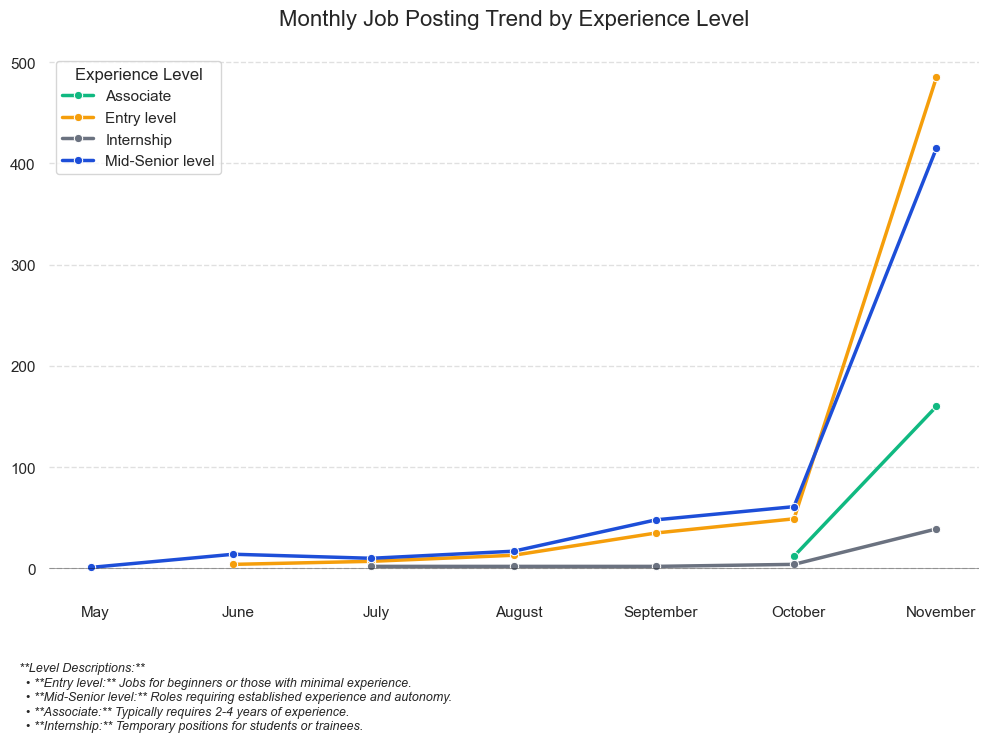

In [64]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# --- Step 1: Load Data ---
FILE_NAME = 'E_Commers_jobs_done.json'

print(f"Loading data from {FILE_NAME}...")
try:
    df = pd.read_json(FILE_NAME)
except FileNotFoundError:
    print(f"Error: {FILE_NAME} not found.")
    exit()
except Exception as e:
    print(f"Error loading JSON: {e}")
    exit()

print(f"Loaded {len(df)} job postings.")

# --- Step 2: Process Dates and Experience ---

# Convert 'PublishedDate' to datetime
df['PublishedDate'] = pd.to_datetime(df['PublishedDate'], errors='coerce')
df = df.dropna(subset=['PublishedDate'])
print(f"Converted {len(df)} rows to datetime objects.")

# Clean 'Experience' column
df['Experience'] = df['Experience'].fillna('Not specified')
df['Experience'] = df['Experience'].replace('', 'Not specified')
df['Experience'] = df['Experience'].replace('N/A', 'Not specified')

# Define categories to plot
categories_to_plot = [
    'Entry level', 
    'Mid-Senior level', 
    'Associate', 
    'Internship'
]

df_filtered = df[df['Experience'].isin(categories_to_plot)].copy()
print(f"Filtered data to {len(df_filtered)} rows with relevant experience levels.")

# --- Step 3: Aggregate Data by Month AND Experience ---
df_filtered = df_filtered.set_index('PublishedDate')
monthly_grouped_counts = df_filtered.groupby('Experience').resample('ME')['Title'].count().reset_index()
monthly_grouped_counts.columns = ['Experience', 'Month', 'Number of Postings']

print("\n--- Aggregated Monthly Counts by Experience ---")
print(monthly_grouped_counts.head())

# Define a manual color palette
color_palette = {
    'Entry level': '#F59E0B',      # Orange
    'Mid-Senior level': '#1D4ED8', # Strong Blue
    'Associate': '#10B981',      # Green/Teal
    'Internship': '#6B7280'      # Grey
}

# --- Step 4: Create the Multi-Line Chart ---
print("\nGenerating plot...")
sns.set_theme(style="white") 

fig, ax = plt.subplots(figsize=(12, 7))

# Create the multi-line plot
ax = sns.lineplot(
    x='Month', 
    y='Number of Postings', 
    hue='Experience', 
    data=monthly_grouped_counts,
    palette=color_palette,
    marker='o',
    linewidth=2.5
)

# --- Step 5: Customize and Save Plot ---
ax.set_title('Monthly Job Posting Trend by Experience Level', fontsize=16, pad=20)
# Remove axis labels
ax.set_xlabel('')
ax.set_ylabel('')

# --- MODIFICATION: Add HORIZONTAL grid lines only ---
# We turn the grid on only for the y-axis
ax.yaxis.grid(True, linestyle='--', alpha=0.6)
# We keep the x-axis grid off
ax.xaxis.grid(False)
# ----------------------------------------------------

# Format x-axis to show month names
date_format = mdates.DateFormatter('%B')
ax.xaxis.set_major_formatter(date_format)

# Tidy up the legend
ax.legend(title='Experience Level', loc='upper left')

# Add subtle horizontal line at y=0
ax.axhline(0, color='black', linewidth=0.5, alpha=0.5)

# Tidy up the axes
sns.despine(left=True, bottom=True)

# Set label rotation to 0 degrees
plt.setp(ax.get_xticklabels(), rotation=0, ha='center')

# Add explanation text below chart
explanation_string = (
    "**Level Descriptions:**\n"
    "  • **Entry level:** Jobs for beginners or those with minimal experience.\n"
    "  • **Mid-Senior level:** Roles requiring established experience and autonomy.\n"
    "  • **Associate:** Typically requires 2-4 years of experience.\n"
    "  • **Internship:** Temporary positions for students or trainees."
)
fig.text(0.1, 0.01, explanation_string, ha="left", va="top", fontsize=9, style='italic', wrap=True)

# Save the figure
output_image = "job_trend_multiline_experience_v4.png"
plt.savefig(output_image, dpi=300, bbox_inches='tight')
print(f"Success! Chart saved as '{output_image}'")

plt.show()

Analysis:
This multi-line chart breaks down the monthly job posting trend by specific experience levels. It provides a deeper insight into the explosive growth seen in the previous chart, showing which experience levels are driving the demand.

This visualization answers key questions about the market's growth:

Is the growth uniform across all levels?

No. The chart clearly shows that while all levels see growth, the boom is overwhelmingly driven by two categories: Entry level (Orange) and Mid-Senior level (Blue). These two lines rise sharply together in October and November, far outpacing the others.

Which level is in highest demand?

The Entry level category experiences the most aggressive growth, finishing in November as the single most in-demand level (approx. 490 jobs). This indicates a massive influx of new positions aimed at junior talent.

Mid-Senior level follows very closely, finishing as the second most in-demand category (approx. 420 jobs). This is a critical insight: companies are not just hiring juniors; they are simultaneously hiring a large number of experienced professionals to manage the growth.

What about other roles?

The Associate level (Teal) follows a similar pattern but on a much smaller scale, showing its own distinct spike in October/November.

The Internship level (Grey) shows only minor, slow growth, indicating that the hiring boom is focused on full-time roles rather than trainee positions.

Conclusion:

The e-commerce job boom in late 2025 is a "dual-track" phenomenon. There is a massive, parallel demand for both Entry level talent to handle the operational workload and Mid-Senior level professionals to provide the necessary strategy and leadership.

## 3.2 Job Distribution by Contract Type (JobType)

Loading data from E_Commers_jobs_done.json...
Loaded 1581 job postings.
Analyzing job types...
Filtered out: ['Not specified']

--- Job Type Counts (Filtered) ---
             Job Type  Count
0           Full-time   1345
1           Part-time    119
3            Contract     31
4          Internship     31
5               Other      9
6           Temporary      1
7  Apprentice/Trainee      1

Generating plot...
Success! Chart saved as 'job_type_barchart_v2.png'


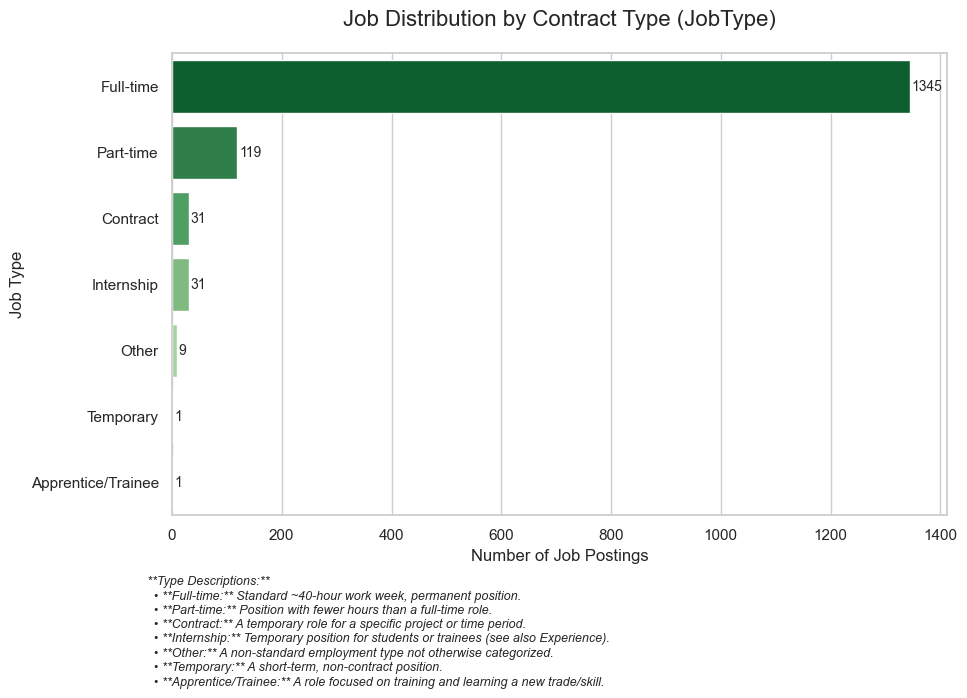

In [32]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- Step 1: Load Data ---
FILE_NAME = 'E_Commers_jobs_done.json'

print(f"Loading data from {FILE_NAME}...")
try:
    df = pd.read_json(FILE_NAME)
except FileNotFoundError:
    print(f"Error: {FILE_NAME} not found.")
    exit()
except Exception as e:
    print(f"Error loading JSON: {e}")
    exit()

print(f"Loaded {len(df)} job postings.")

# --- Step 2: Process and Count Job Types ---

# Handle missing or empty values
df['JobType'] = df['JobType'].fillna('Not specified')
df['JobType'] = df['JobType'].replace('', 'Not specified')
df['JobType'] = df['JobType'].replace('N/A', 'Not specified') # Group N/A

print("Analyzing job types...")
# Count the frequency
job_type_counts = df['JobType'].value_counts()

# --- Step 3: Prepare Data for Plotting ---
# Format as a DataFrame
job_type_df = job_type_counts.reset_index()
job_type_df.columns = ['Job Type', 'Count']

# --- Filter out categories ---
# We'll remove 'Not specified' from the plot
exclude_list = ['Not specified']
job_type_df_filtered = job_type_df[~job_type_df['Job Type'].isin(exclude_list)].copy()
print(f"Filtered out: {exclude_list}")

print("\n--- Job Type Counts (Filtered) ---")
print(job_type_df_filtered)

# --- Step 4: Create the Horizontal Bar Chart ---
print("\nGenerating plot...")
sns.set_theme(style="whitegrid")

# Create figure
fig, ax = plt.subplots(figsize=(10, 6)) # Adjust size if needed

# Fix for seaborn FutureWarning
ax = sns.barplot(
    x='Count', 
    y='Job Type', 
    data=job_type_df_filtered, # Use the filtered data
    palette="Greens_r", 
    hue='Job Type', 
    legend=False          
)

# --- Step 5: Customize and Save Plot ---
ax.set_title('Job Distribution by Contract Type (JobType)', fontsize=16, pad=20)
ax.set_xlabel('Number of Job Postings', fontsize=12)
ax.set_ylabel('Job Type', fontsize=12)

# Add Data Labels (the count) on the bars
for p in ax.patches:
    width = p.get_width()
    ax.annotate(
        f'{int(width)}',
        (width + 3, p.get_y() + p.get_height() / 2),
        ha='left',
        va='center',
        fontsize=10
    )

# --- MODIFICATION: Add left-aligned explanation text ---
# Create the explanation string
explanation_string = (
    "**Type Descriptions:**\n"
    "  • **Full-time:** Standard ~40-hour work week, permanent position.\n"
    "  • **Part-time:** Position with fewer hours than a full-time role.\n"
    "  • **Contract:** A temporary role for a specific project or time period.\n"
    "  • **Internship:** Temporary position for students or trainees (see also Experience).\n"
    "  • **Other:** A non-standard employment type not otherwise categorized.\n"
    "  • **Temporary:** A short-term, non-contract position.\n"
    "  • **Apprentice/Trainee:** A role focused on training and learning a new trade/skill."
)

# Add the text to the figure, positioned at the bottom-left
fig.text(0.1, 0.01, explanation_string, ha="left", va="top", fontsize=9, style='italic', wrap=True)
# -----------------------------------------------------------


# Save the figure
output_image = "job_type_barchart_v2.png"
# We must use bbox_inches='tight' to ensure the figtext is included
plt.savefig(output_image, dpi=300, bbox_inches='tight')
print(f"Success! Chart saved as '{output_image}'")

plt.show()

Analysis:
This bar chart breaks down the job postings by the type of contract offered. The results are definitive and paint a clear picture of the employment landscape in the e-commerce sector.

This visualization answers the question: "What kind of employment contracts are companies offering?"

What is the dominant contract type?

The market is almost entirely composed of Full-time positions (1345 jobs). This overwhelming majority (over 85% of the total filtered jobs) signals that companies are hiring for stable, long-term, and permanent roles.

What about non-permanent or flexible roles?

All other contract types are comparatively rare. Part-time (119 jobs) is the only other significant category, though it is dwarfed by full-time roles.

Specialized roles like Contract (31) and Internship (31) represent a very small fraction of the market, as do niche categories like "Temporary" and "Apprentice."

Conclusion:

The e-commerce job market in Germany is not a "gig economy." The demand is for a stable, full-time workforce. This indicates that companies are investing heavily in building dedicated, in-house teams for the long haul, rather than filling gaps with temporary or contract-based workers.

## 3.3 Job Distribution by Work Type

Loading data from E_Commers_jobs_done.json...
Loaded 1581 job postings.
Analyzing work types...
Wrapped long labels at 30 characters.

--- Top 15 Work Type Counts (Filtered) ---
                                            Work Type  Count
0                                           Marketing    411
1                                 Marketing and Sales    196
2                                               Other    137
3                                    Customer Service    115
4                      Sales and Business Development    112
5                                               Sales    102
6   Marketing, Public Relations,\nand Writing/Editing     59
7                              Information Technology     50
9                        Management and Manufacturing     40
10                                     Administrative     34
11                Sales, Other, and Customer\nService     13
12                             Education and Training     13
13                           

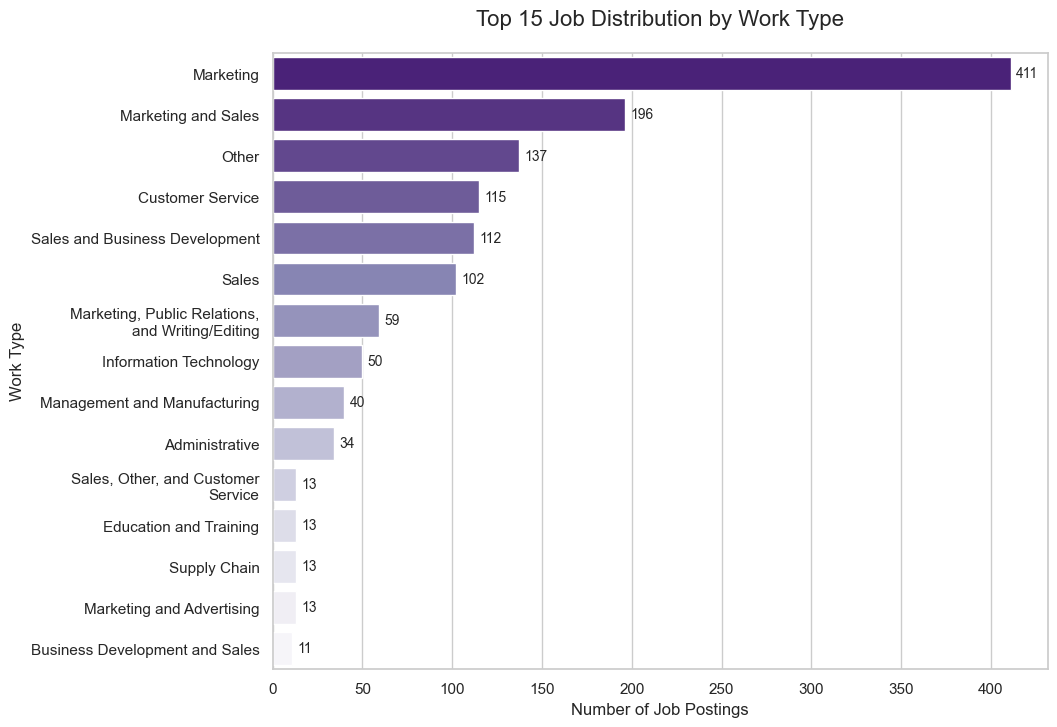

In [35]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import textwrap # We import the textwrap library

# --- Step 1: Load Data ---
FILE_NAME = 'E_Commers_jobs_done.json'

print(f"Loading data from {FILE_NAME}...")
try:
    df = pd.read_json(FILE_NAME)
except FileNotFoundError:
    print(f"Error: {FILE_NAME} not found.")
    exit()
except Exception as e:
    print(f"Error loading JSON: {e}")
    exit()

print(f"Loaded {len(df)} job postings.")

# --- Step 2: Process and Count Work Types ---

# Handle missing or empty values
df['WorkType'] = df['WorkType'].fillna('Not specified')
df['WorkType'] = df['WorkType'].replace('', 'Not specified')
df['WorkType'] = df['WorkType'].replace('N/A', 'Not specified') # Group N/A

print("Analyzing work types...")
# Count the frequency
work_type_counts = df['WorkType'].value_counts()

# --- Step 3: Prepare Data for Plotting ---
# Format as a DataFrame
work_type_df = work_type_counts.reset_index()
work_type_df.columns = ['Work Type', 'Count']

# Filter out categories
exclude_list = ['Not specified']
work_type_df_filtered = work_type_df[~work_type_df['Work Type'].isin(exclude_list)].copy()

# Plot the Top 15
TOP_N = 15
work_type_df_filtered = work_type_df_filtered.head(TOP_N)

# --- MODIFICATION: Wrap long labels ---
# We define a width (in characters) to wrap at
WRAP_WIDTH = 30 

# We use textwrap.wrap() to get a list of lines
# Then we join them with the newline character '\n'
work_type_df_filtered['Work Type'] = work_type_df_filtered['Work Type'].apply(
    lambda s: '\n'.join(textwrap.wrap(s, width=WRAP_WIDTH))
)
print(f"Wrapped long labels at {WRAP_WIDTH} characters.")
# ---------------------------------------------

print(f"\n--- Top {TOP_N} Work Type Counts (Filtered) ---")
print(work_type_df_filtered)

# --- Step 4: Create the Horizontal Bar Chart ---
print("\nGenerating plot...")
sns.set_theme(style="whitegrid")

# Create figure
fig, ax = plt.subplots(figsize=(10, 8)) 

# The plot will automatically have more space for bars
# because the y-labels are now "thinner"
ax = sns.barplot(
    x='Count', 
    y='Work Type', 
    data=work_type_df_filtered,
    palette="Purples_r",
    hue='Work Type', 
    legend=False          
)

# --- Step 5: Customize and Save Plot ---
ax.set_title(f'Top {TOP_N} Job Distribution by Work Type', fontsize=16, pad=20)
ax.set_xlabel('Number of Job Postings', fontsize=12)
ax.set_ylabel('Work Type', fontsize=12)

# Add Data Labels (the count) on the bars
for p in ax.patches:
    width = p.get_width()
    ax.annotate(
        f'{int(width)}',
        (width + 3, p.get_y() + p.get_height() / 2),
        ha='left',
        va='center',
        fontsize=10
    )

# Save the figure
output_image = "work_type_barchart_v3_wrap.png"
plt.savefig(output_image, dpi=300, bbox_inches='tight')
print(f"Success! Chart saved as '{output_image}'")

plt.show()

Analysis:
This chart breaks down the job postings by the functional department or "Work Type." It clearly shows which business units are most involved in e-commerce operations.

This visualization answers the question: "Which departments are hiring the most for e-commerce roles?"

What is the dominant function?

The e-commerce sector is overwhelmingly Marketing-driven. Marketing (411 jobs) is the single largest category by a massive margin. When combined with related functions like Marketing and Sales (196) and Sales (102), it's clear that the primary focus of these roles is on customer acquisition and promotion.

What are the key support functions?

Customer-facing and growth-oriented roles are essential. Customer Service (115) and Sales and Business Development (112) are the next major independent categories, highlighting the importance of both retaining customers and expanding the business.

What other areas are involved?

The chart shows that e-commerce is not just marketing; it requires technical and operational support. Information Technology (50), Management and Manufacturing (40), and Supply Chain (13) are all represented, indicating the need for a complete business ecosystem to support online sales. The "Other" category (137) is also large, suggesting a wide variety of unclassified or hybrid roles.

Conclusion:

This distribution confirms that e-commerce is, first and foremost, a Marketing and Sales endeavor. However, its success relies on a network of supporting departments, including Customer Service, IT, and Logistics/Supply Chain, making it a truly cross-functional part of a business.

## 3.4 Job Distribution by Source

Loading data from E_Commers_jobs_done.json...
Loaded 1581 job postings.
Analyzing sources...

--- Source Counts (Filtered) ---
Source
linkedin     1496
glassdoor      49
stepstone      36
Name: count, dtype: int64

Generating pie chart...
Success! Chart saved as 'source_pie_chart_v3.png'


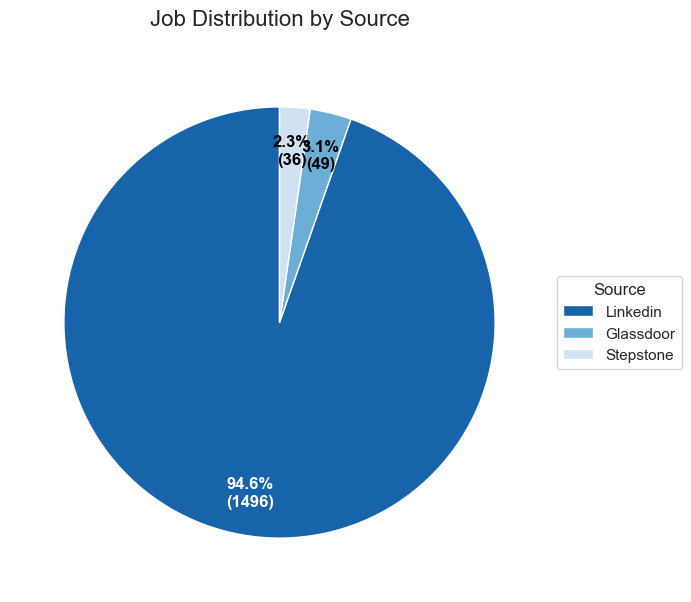

In [41]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Step 1: Load Data ---
FILE_NAME = 'E_Commers_jobs_done.json'

print(f"Loading data from {FILE_NAME}...")
try:
    df = pd.read_json(FILE_NAME)
except FileNotFoundError:
    print(f"Error: {FILE_NAME} not found.")
    exit()
except Exception as e:
    print(f"Error loading JSON: {e}")
    exit()

print(f"Loaded {len(df)} job postings.")

# --- Step 2: Process and Count Sources ---

# Handle missing or empty values
df['Source'] = df['Source'].fillna('Not specified')
df['Source'] = df['Source'].replace('', 'Not specified')
df['Source'] = df['Source'].replace('N/A', 'Not specified') # Group N/A

print("Analyzing sources...")
# Count the frequency
source_counts = df['Source'].value_counts()

# --- Step 3: Prepare Data for Plotting ---
# Filter out 'Not specified'
exclude_list = ['Not specified']
source_counts_filtered = source_counts[~source_counts.index.isin(exclude_list)]

print("\n--- Source Counts (Filtered) ---")
print(source_counts_filtered)

# Prepare data for pie chart
labels = [l.capitalize() for l in source_counts_filtered.index]
sizes = source_counts_filtered.values

# --- Step 4: Create the Pie Chart ---
print("\nGenerating pie chart...")
# Create figure
fig, ax = plt.subplots(figsize=(10, 7), subplot_kw=dict(aspect="equal"))

# Define colors
colors = plt.get_cmap('Blues_r')([0.2, 0.5, 0.8]) 

# Custom autopct function
def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        absolute_value = int(round(pct/100.*total))
        return f"{pct:.1f}%\n({absolute_value})"
    return my_autopct

# --- MODIFICATION 1: Remove 'labels=' ---
# We will use a legend instead of labels on the chart
wedges, texts, autotexts = ax.pie(
    sizes, 
    autopct=make_autopct(sizes), 
    startangle=90,
    colors=colors,
    pctdistance=0.8, # Move text a bit inside
    wedgeprops={'edgecolor': 'white', 'linewidth': 1}
)

# --- MODIFICATION 2: Dynamic Text Color ---
# Iterate over the percentage labels (autotexts)
total_size = sum(sizes)
for i, autotext_label in enumerate(autotexts):
    # Get the percentage for this slice
    pct = (sizes[i] / total_size) * 100
    
    if pct < 10:
        # If the slice is small (light color)
        autotext_label.set_color('black') # Use black text
    else:
        # If the slice is large (dark color)
        autotext_label.set_color('white') # Use white text
    
    autotext_label.set_weight('bold')
# ---------------------------------------------

# --- Step 5: Customize and Save Plot ---
ax.set_title('Job Distribution by Source', fontsize=16, pad=20)

# --- MODIFICATION 3: Add a Legend ---
# Add a legend to the right of the plot
ax.legend(
    wedges, 
    labels, 
    title="Source", 
    loc="center left", # Position
    bbox_to_anchor=(1, 0, 0.5, 1) # Place it outside the pie
)
# ------------------------------------

# Save the figure
output_image = "source_pie_chart_v3.png"
plt.savefig(output_image, dpi=300, bbox_inches='tight')
print(f"Success! Chart saved as '{output_image}'")

plt.show()

Analysis:
This pie chart illustrates the origin of the job postings in the filtered dataset, showing the breakdown by source platform.

This visualization answers the question: "Where did the job data for this analysis come from?"

What is the dominant source?

The data is overwhelmingly sourced from LinkedIn, which accounts for 94.6% (1496 jobs) of all postings.

What about other sources?

Glassdoor (3.1%) and Stepstone (2.3%) make up a very small fraction of the total data.

Conclusion & Caveat:

This chart is crucial for interpreting the entire analysis. It shows that the dataset is not an equal representation of the entire German e-commerce job market, but rather a deep dive into the market as seen on LinkedIn.

All conclusions drawn (about top skills, regions, etc.) are highly representative of what companies post on LinkedIn, but may not fully capture trends that are unique to other platforms like Stepstone or Glassdoor.

## 3.5 Top N Companies Hiring in E-Commerce

This section analyzes the key employers driving demand in the e-commerce sector, first by identifying the top individual companies and then by examining their market share within Germany's key regions.

Loading data from E_Commers_jobs_done.json...
Loaded 1581 job postings.
Analyzing company names...
Filtered out: ['Not specified']

--- Top 20 Companies (Filtered) ---
                    Company  Count
0      Masters of Marketing    100
1   Abercrombie & Fitch Co.     87
2        Nuvare Consultancy     24
3    Max Mara Fashion Group     21
4   FH Collective - Academy     16
5                  Instaffo     15
6            CheckCars24.de     12
7    ZUFALL logistics group     12
8      ID Logistics Germany     10
9                   Zalando      9
10             MAILODY GmbH      8
11   riess-ambiente.de GmbH      7
12                 Westwing      7
13    MarketConsultive GmbH      6
14                   Pammys      6
15                Soulhouse      6
16                    SHEKO      6
17                Canonical      6
18                   Digitl      6
19             Arineo Group      6

Generating plot...
Success! Chart saved as 'top_companies_barchart_v2.png'


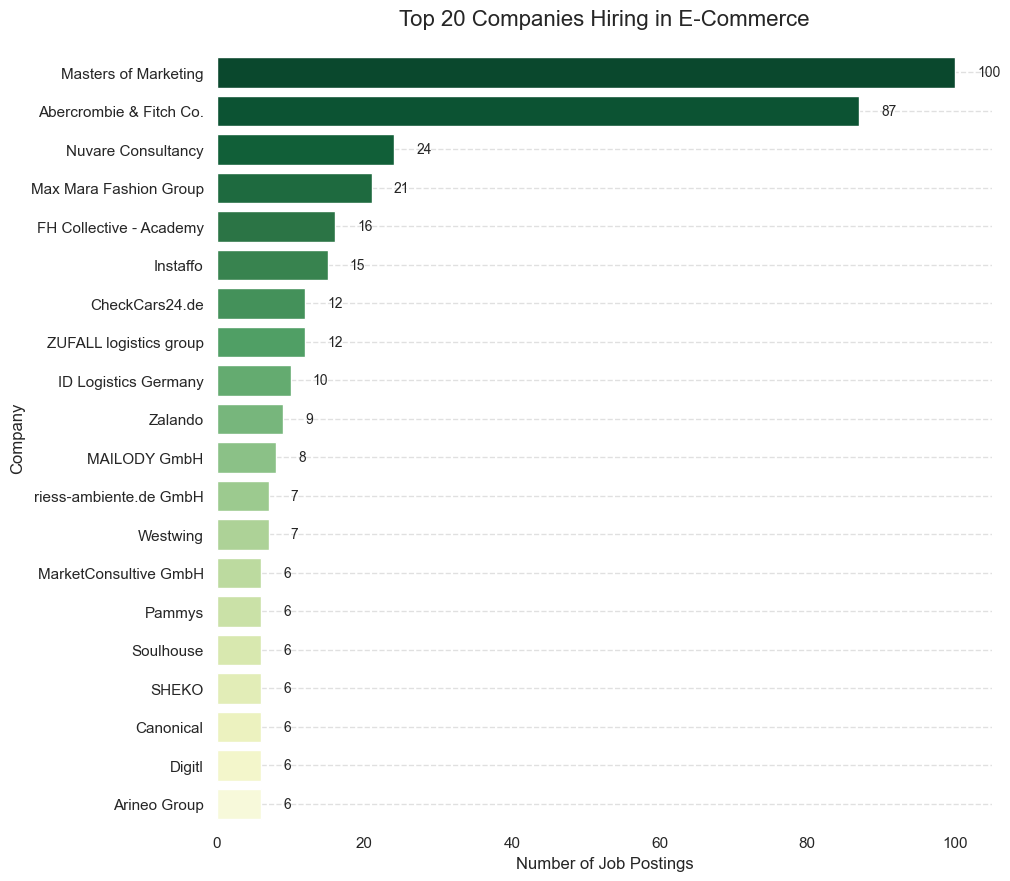

In [82]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- Step 1: Load Data ---
FILE_NAME = 'E_Commers_jobs_done.json'
TOP_N = 20 # How many top companies to plot

print(f"Loading data from {FILE_NAME}...")
try:
    df = pd.read_json(FILE_NAME)
except FileNotFoundError:
    print(f"Error: {FILE_NAME} not found.")
    exit()
except Exception as e:
    print(f"Error loading JSON: {e}")
    exit()

print(f"Loaded {len(df)} job postings.")

# --- Step 2: Process and Count Company Names ---

# Handle missing or empty values
df['CompanyName'] = df['CompanyName'].fillna('Not specified')
df['CompanyName'] = df['CompanyName'].replace('', 'Not specified')

print("Analyzing company names...")
# Count the frequency
company_counts = df['CompanyName'].value_counts()

# --- Step 3: Prepare Data for Plotting ---
# Format as a DataFrame
company_df = company_counts.reset_index()
company_df.columns = ['Company', 'Count']

# --- Filter out 'Not specified' ---
exclude_list = ['Not specified']
company_df_filtered = company_df[~company_df['Company'].isin(exclude_list)].copy()
print(f"Filtered out: {exclude_list}")

# Select the Top N from the filtered list
top_companies_df = company_df_filtered.head(TOP_N)

print(f"\n--- Top {TOP_N} Companies (Filtered) ---")
print(top_companies_df)

# --- Step 4: Create the Horizontal Bar Chart ---
print("\nGenerating plot...")
sns.set_theme(style="whitegrid") # We start with whitegrid

# Create figure
fig, ax = plt.subplots(figsize=(10, 10)) 

# Fix for seaborn FutureWarning
ax = sns.barplot(
    x='Count', 
    y='Company', 
    data=top_companies_df,
    palette="YlGn_r", 
    hue='Company', 
    legend=False          
)

# --- Step 5: Customize and Save Plot ---
ax.set_title(f'Top {TOP_N} Companies Hiring in E-Commerce', fontsize=16, pad=20)
ax.set_xlabel('Number of Job Postings', fontsize=12)
ax.set_ylabel('Company', fontsize=12)

# Add Data Labels (the count) on the bars
for p in ax.patches:
    width = p.get_width()
    ax.annotate(
        f'{int(width)}',
        (width + 3, p.get_y() + p.get_height() / 2),
        ha='left',
        va='center',
        fontsize=10
    )

# --- MODIFICATION: Remove vertical grid lines ---
# This disables the grid on the x-axis (vertical lines)
ax.xaxis.grid(False)
# This explicitly keeps the grid on the y-axis (horizontal lines)
ax.yaxis.grid(True, linestyle='--', alpha=0.6)
# -------------------------------------------------

# Tidy up spines
sns.despine(bottom=True, left=True)

# Save the figure
output_image = "top_companies_barchart_v2.png"
plt.savefig(output_image, dpi=300, bbox_inches='tight')
print(f"Success! Chart saved as '{output_image}'")

plt.show()

Analysis: Top 20 Hirers
This bar chart ranks the specific companies by their total job postings. The results show a "long-tail" distribution, typical of a fragmented market.

Key Players: The field is led by a few significant hirers, notably "Masters of Marketing" (100 jobs) and "Abercrombie & Fitch Co." (87 jobs).

Market Diversity: After the top two, the numbers drop off sharply, showing a diverse landscape of agencies ("Nuvare Consultancy"), fashion groups ("Max Mara Fashion Group"), and logistics providers ("ZUFALL logistics group").

Initial Conclusion: The data suggests that the market is not dominated by a few large corporations but is instead highly diverse.

Loading data from E_Commers_jobs_done.json...
Loaded 1581 job postings.

--- Top 5 Regions ---
Index(['Berlin', 'North Rhine-Westphalia', 'Bavaria', 'Baden-Württemberg',
       'Hamburg'],
      dtype='object', name='region')

--- Top 5 Companies ---
Index(['Masters of Marketing', 'Abercrombie & Fitch Co.', 'Nuvare Consultancy',
       'Max Mara Fashion Group', 'FH Collective - Academy'],
      dtype='object', name='CompanyName')

Filtered and grouped data for plotting.
Generating plot...
Success! Chart saved as 'stacked_bar_company_region.png'


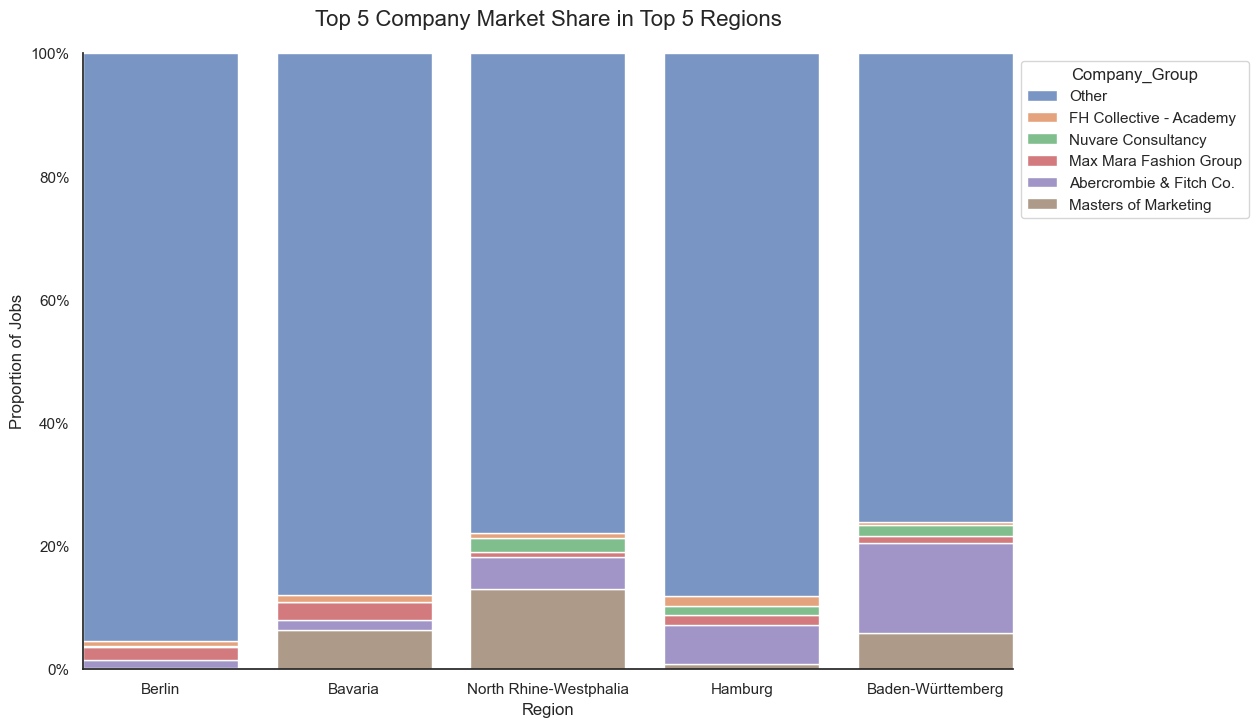

In [85]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter # To format the Y-axis as 100%

# --- Step 1: Load Data ---
FILE_NAME = 'E_Commers_jobs_done.json'
TOP_N = 5 # Top 5 regions and Top 5 companies

print(f"Loading data from {FILE_NAME}...")
try:
    df = pd.read_json(FILE_NAME)
except FileNotFoundError:
    print(f"Error: {FILE_NAME} not found.")
    exit()
except Exception as e:
    print(f"Error loading JSON: {e}")
    exit()

print(f"Loaded {len(df)} job postings.")

# --- Step 2: Clean and Find Top 5s ---

# Clean and find Top 5 Regions
df['region'] = df['region'].fillna('Not specified')
top_5_regions = df[df['region'] != 'Not specified']['region'].value_counts().head(TOP_N).index
print(f"\n--- Top {TOP_N} Regions ---")
print(top_5_regions)

# Clean and find Top 5 Companies
df['CompanyName'] = df['CompanyName'].fillna('Not specified')
top_5_companies = df[df['CompanyName'] != 'Not specified']['CompanyName'].value_counts().head(TOP_N).index
print(f"\n--- Top {TOP_N} Companies ---")
print(top_5_companies)

# --- Step 3: Prepare Data for Plotting ---

# 1. Filter the DataFrame to ONLY include the Top 5 Regions
df_plot = df[df['region'].isin(top_5_regions)].copy()

# 2. Create a new 'Company_Group' column
# If a company is not in the Top 5, label it as 'Other'
df_plot['Company_Group'] = df_plot['CompanyName'].apply(
    lambda name: name if name in top_5_companies else 'Other'
)

print("\nFiltered and grouped data for plotting.")

# --- Step 4: Create the 100% Stacked Bar Chart ---
print("Generating plot...")
sns.set_theme(style="white") # Use a clean white style

fig, ax = plt.subplots(figsize=(12, 8)) # width, height

# Create the plot
# 'histplot' with 'multiple="fill"' automatically creates a 100% stacked bar chart
sns.histplot(
    data=df_plot,
    x='region',       # The 5 bars
    hue='Company_Group', # The 6 colors (Top 5 + Other)
    multiple="fill",  # This is the magic for 100% stacking
    shrink=0.8,       # Makes bars slightly thinner
    ax=ax
)

# --- Step 5: Customize and Save Plot ---
ax.set_title(f'Top {TOP_N} Company Market Share in Top {TOP_N} Regions', fontsize=16, pad=20)
ax.set_xlabel('Region', fontsize=12)
ax.set_ylabel('Proportion of Jobs', fontsize=12)

# Format the Y-axis to show percentages
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))

# Move the legend outside the plot
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

# Tidy up spines
sns.despine()

# Save the figure
output_image = "stacked_bar_company_region.png"
plt.savefig(output_image, dpi=300, bbox_inches='tight')
print(f"Success! Chart saved as '{output_image}'")

plt.show()

Analysis 2: Market Share in Key Regions
This 100% stacked bar chart confirms the "fragmented market" hypothesis. It analyzes the composition of the job market within the Top 5 regions (by job volume).

The "Other" Category: The most significant finding is the dominance of the "Other" category (the large blue segment). In every single key region—including Berlin and Bavaria—the Top 5 companies combined account for less than 20-25% of the total job postings.

Final Conclusion: While it is useful to identify the top individual hirers, this analysis definitively proves that the German e-commerce job market is highly fragmented. The vast majority of opportunities are not with a few large "big tech" giants, but are distributed across hundreds of small, medium, and specialized businesses, which collectively form the backbone of the industry.

# 4. Temporal Analysis (Trends)

## 4.1 Job Posting Trend (Last 6 Months)

Loading data from E_Commers_jobs_done.json...
Loaded 1581 job postings.
Converted 1496 rows to datetime objects.

--- Aggregated Weekly Counts ---
  Week Ending  Number of Postings
0  2025-05-04                   2
1  2025-05-11                   5
2  2025-05-18                   2
3  2025-05-25                   5
4  2025-06-01                   5

Generating plot...
Success! Chart saved as 'job_trend_linechart_v6_weekly.png'


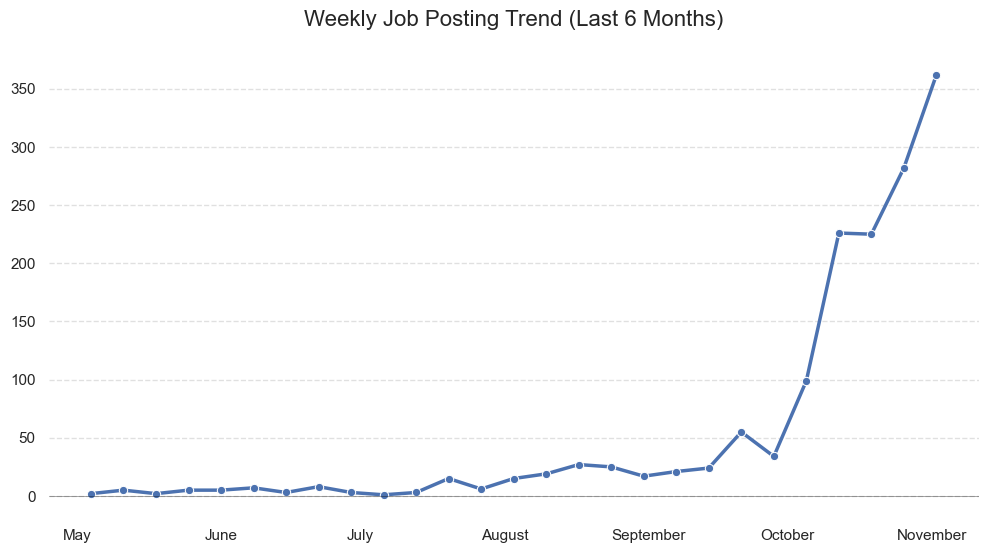

In [86]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# --- Step 1: Load Data ---
FILE_NAME = 'E_Commers_jobs_done.json'

print(f"Loading data from {FILE_NAME}...")
try:
    df = pd.read_json(FILE_NAME)
except FileNotFoundError:
    print(f"Error: {FILE_NAME} not found.")
    exit()
except Exception as e:
    print(f"Error loading JSON: {e}")
    exit()

print(f"Loaded {len(df)} job postings.")

# --- Step 2: Process Dates ---
df['PublishedDate'] = pd.to_datetime(df['PublishedDate'], errors='coerce')
df = df.dropna(subset=['PublishedDate'])
print(f"Converted {len(df)} rows to datetime objects.")

# --- Step 3: Aggregate Data by Week ---
df = df.set_index('PublishedDate')
weekly_counts = df.resample('W')['Title'].count().reset_index()
weekly_counts.columns = ['Week Ending', 'Number of Postings']
print("\n--- Aggregated Weekly Counts ---")
print(weekly_counts.head())

# --- Step 4: Create the Line Chart ---
print("\nGenerating plot...")
sns.set_theme(style="white") 

fig, ax = plt.subplots(figsize=(12, 6))

ax = sns.lineplot(
    x='Week Ending', 
    y='Number of Postings', 
    data=weekly_counts,
    marker='o',
    linewidth=2.5
)

# --- Step 5: Customize and Save Plot ---
ax.set_title('Weekly Job Posting Trend (Last 6 Months)', fontsize=16, pad=20)

# Remove axis labels
ax.set_xlabel('') 
ax.set_ylabel('')

# --- MODIFICATION 1: Add HORIZONTAL grid lines only ---
ax.yaxis.grid(True, linestyle='--', alpha=0.6)
ax.xaxis.grid(False)
# -----------------------------------------------------

# Format x-axis to show month names
date_format = mdates.DateFormatter('%B')
ax.xaxis.set_major_formatter(date_format)

# Add a subtle horizontal line at y=0
ax.axhline(0, color='black', linewidth=0.5, alpha=0.5)

# Tidy up the axes
sns.despine(left=True, bottom=True)

# --- MODIFICATION 2: Set label rotation to 0 degrees ---
# fig.autofmt_xdate() # Removed
plt.setp(ax.get_xticklabels(), rotation=0, ha='center')
# -----------------------------------------------------

# Save the figure
output_image = "job_trend_linechart_v6_weekly.png"
plt.savefig(output_image, dpi=300, bbox_inches='tight')
print(f"Success! Chart saved as '{output_image}'")

plt.show()

Loading data from E_Commers_jobs_done.json...
Loaded 1581 job postings.
Converted 1496 rows to datetime objects.

--- Aggregated Monthly Counts ---
       Month  Number of Postings
0 2025-04-30                   1
1 2025-05-31                  18
2 2025-06-30                  21
3 2025-07-31                  37
4 2025-08-31                  91
5 2025-09-30                 148
6 2025-10-31                1180

Generating plot...
Success! Chart saved as 'job_trend_linechart_monthly_v5.png'


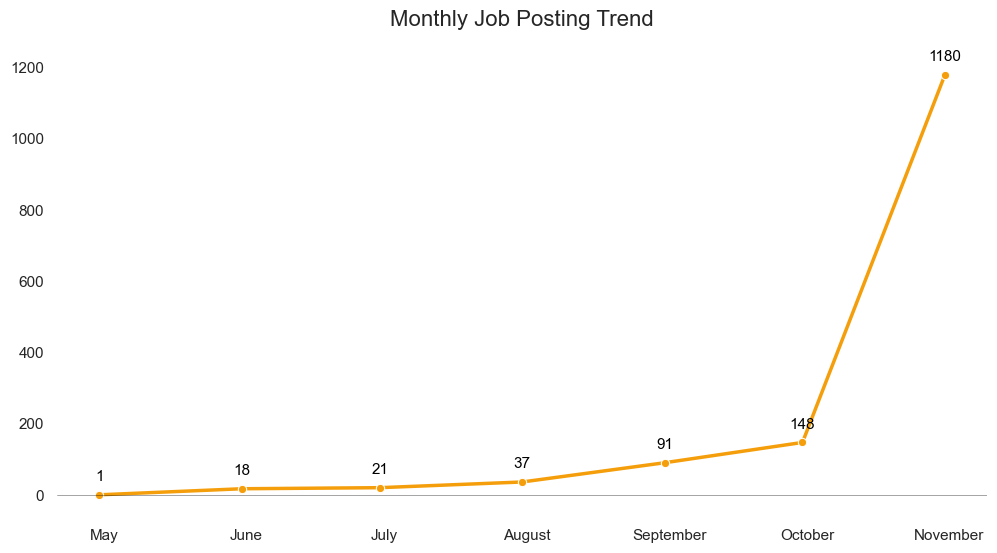

In [58]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# --- Step 1: Load Data ---
FILE_NAME = 'E_Commers_jobs_done.json'

print(f"Loading data from {FILE_NAME}...")
try:
    df = pd.read_json(FILE_NAME)
except FileNotFoundError:
    print(f"Error: {FILE_NAME} not found.")
    exit()
except Exception as e:
    print(f"Error loading JSON: {e}")
    exit()

print(f"Loaded {len(df)} job postings.")

# --- Step 2: Process Dates ---
df['PublishedDate'] = pd.to_datetime(df['PublishedDate'], errors='coerce')
df = df.dropna(subset=['PublishedDate'])
print(f"Converted {len(df)} rows to datetime objects.")

# --- Step 3: Aggregate Data by Month ---
df = df.set_index('PublishedDate')

# Resample by 'ME' (Month End)
monthly_counts = df.resample('ME')['Title'].count().reset_index()
monthly_counts.columns = ['Month', 'Number of Postings']

print("\n--- Aggregated Monthly Counts ---")
print(monthly_counts)

# --- Step 4: Create the Line Chart ---
print("\nGenerating plot...")
sns.set_theme(style="white") 

fig, ax = plt.subplots(figsize=(12, 6))

ax = sns.lineplot(
    x='Month', 
    y='Number of Postings', 
    data=monthly_counts,
    marker='o',
    linewidth=2.5,
    color='#F59E0B' # --- MODIFICATION 1: Change line color to orange ---
)

# --- Step 5: Customize and Save Plot ---
ax.set_title('Monthly Job Posting Trend', fontsize=16, pad=20)

# Remove axis labels
ax.set_xlabel('') 
ax.set_ylabel('')

# Remove grid lines
ax.grid(False)

# Add data labels (larger font, black color)
for index, row in monthly_counts.iterrows():
    ax.annotate(
        text=f"{int(row['Number of Postings'])}",
        xy=(row['Month'], row['Number of Postings']),
        xytext=(0, 10),
        textcoords="offset points",
        ha='center',
        fontsize=11,
        color='black'
    )

# Format x-axis to show month names
date_format = mdates.DateFormatter('%B')
ax.xaxis.set_major_formatter(date_format)

# Add a subtle horizontal line at y=0
ax.axhline(0, color='black', linewidth=0.5, alpha=0.5)

# Tidy up the axes
sns.despine(left=True, bottom=True)

# --- MODIFICATION 2: Set label rotation to 0 degrees ---
# We remove autofmt_xdate() and manually set the rotation
# fig.autofmt_xdate() # Removed
plt.setp(ax.get_xticklabels(), rotation=0, ha='center')
# --------------------------------------------------------

# Save the figure
output_image = "job_trend_linechart_monthly_v5.png"
plt.savefig(output_image, dpi=300, bbox_inches='tight')
print(f"Success! Chart saved as '{output_image}'")

plt.show()

Analysis:
This section analyzes the change in job posting volume over the 6-month period using two complementary views: a monthly chart for the overall trend and a weekly chart for short-term volatility.

The analysis reveals a dramatic "hockey stick" growth pattern:

Stagnant Period (May - September): The e-commerce job market was stable but stagnant for most of the period. The monthly chart shows a baseline of fewer than 100 new jobs per month. The weekly chart confirms this, showing minor fluctuations but a consistent, low volume of activity.

Exponential Boom (October - November): A massive hiring boom began abruptly in October. The weekly chart pinpoints this "take-off" moment. The monthly chart quantifies the sheer scale of this growth, jumping from 91 postings in September to 148 in October, and then exploding to 1180 postings in November.

Conclusion: This trend indicates a significant and sudden wave of strategic investment and expansion across the e-commerce sector towards the end of the year, transforming it from a slow-moving market to a high-growth one in just a few weeks.

# 5. Job Title Frequency and Market Segmentation

This analysis fulfills the final project requirement by identifying the exact, most frequent job title formulations used in the market. By quantifying these titles, we can segment the demand and clarify the core functions being hired for.

Loading data from E_Commers_jobs_done.json...
Loaded 1581 job postings.
Analyzing job titles...
Wrapped long labels at 35 characters.

--- Top 20 Job Titles (Cleaned & Wrapped) ---
                                            Job Title  Count
0                            Online Marketing Manager     38
1   Content SEO Strategist (m/w/d) –\nFokus auf Su...     21
2   AI-Content-Optimization Manager\n(m/w/d) – Fok...     20
3                           Digital Marketing Manager     19
4   Online Marketing Manager –\nSchwerpunkt Social...     18
5   SEO & AI Integration Specialist\n(m/w/d) (Quer...     18
6                                  E-Commerce Manager     16
7   Marketing Manager Digital & Social\nMedia (m/w...     16
8                                Social Media Manager     15
9   German Speaking Digital Marketing\nSpecialist ...      9
10  Digital Marketing Ads Specialist -\nGerman Mar...      9
11  Junior German Digital Marketing &\nAds Special...      8
12      E-Mail Marketing /

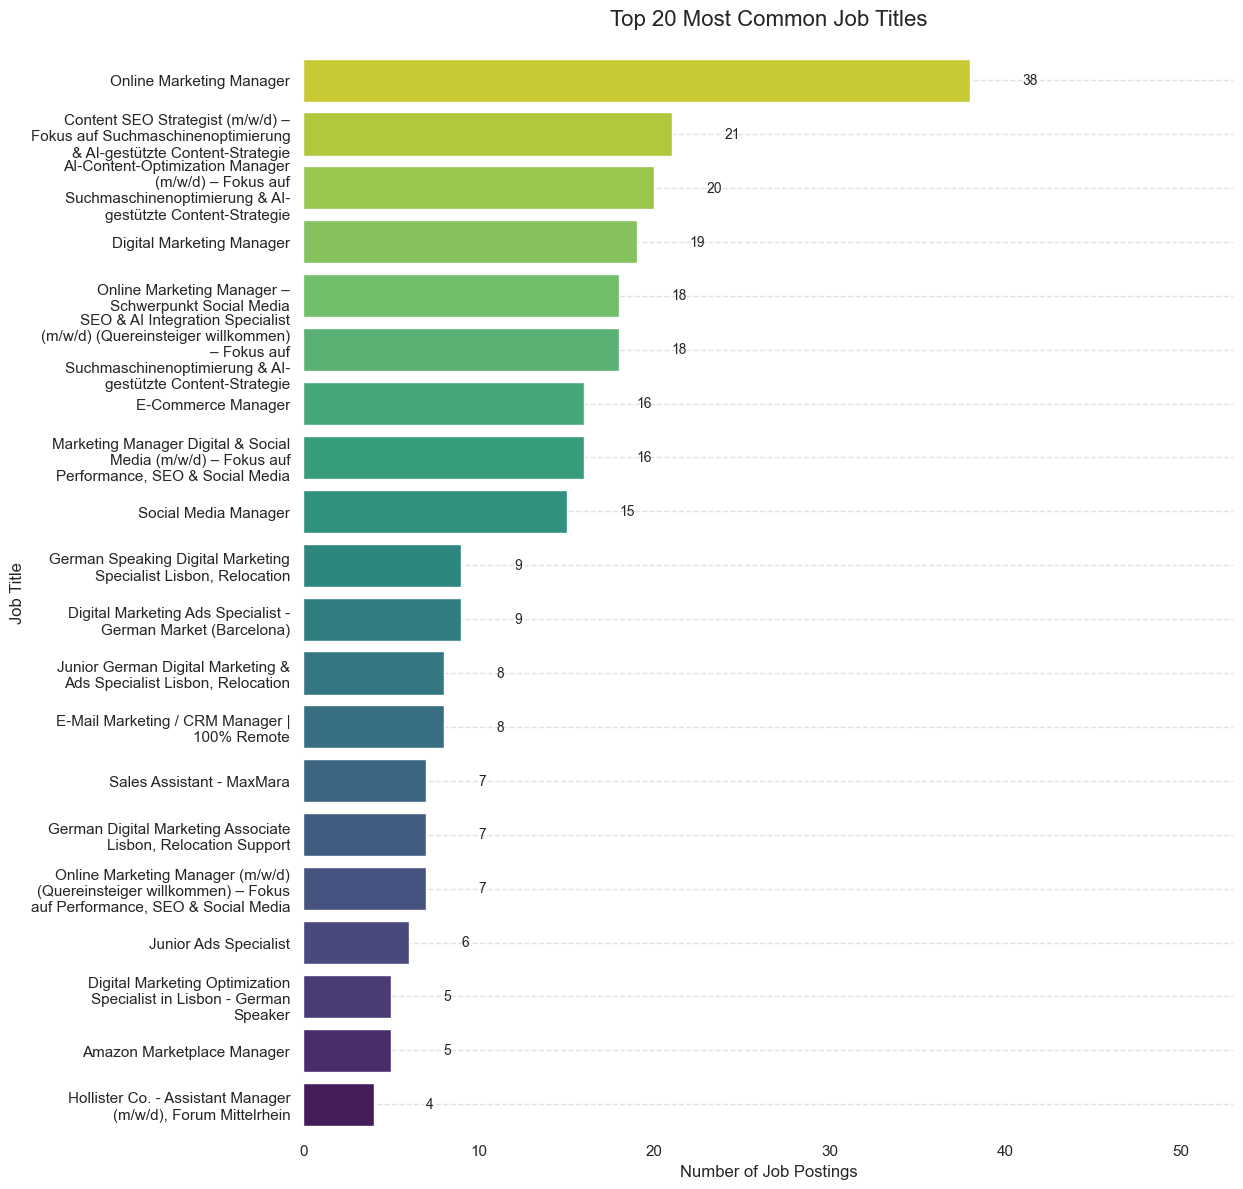

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re 
import textwrap 

# --- Step 1: Load Data ---
FILE_NAME = 'E_Commers_jobs_done.json'
TOP_N = 20 

print(f"Loading data from {FILE_NAME}...")
try:
    df = pd.read_json(FILE_NAME)
except FileNotFoundError:
    print(f"Error: {FILE_NAME} not found.")
    exit()
except Exception as e:
    print(f"Error loading JSON: {e}")
    exit()

print(f"Loaded {len(df)} job postings.")

# --- Step 2: Clean and Count Job Titles ---

# Handle missing or empty values
df['Title'] = df['Title'].fillna('Not specified')
df['Title'] = df['Title'].replace('', 'Not specified')

print("Analyzing job titles...")

def clean_title(title):
    """ Cleans a job title by removing common suffixes. """
    if not isinstance(title, str):
        return 'Not specified'
    
    # Remove common suffixes
    title = re.sub(r'\s*\([m/f/d/w/a/l/g/e/n/r/s]+\)\s*$', '', title, flags=re.IGNORECASE)
    title = title.strip()
    
    return title

# Apply the cleaning function
df['Title_Cleaned'] = df['Title'].apply(clean_title)

# Count the frequency of the *cleaned* titles
title_counts = df['Title_Cleaned'].value_counts()

# --- Step 3: Prepare Data for Plotting ---
# Format as a DataFrame
title_df = title_counts.reset_index()
title_df.columns = ['Job Title', 'Count']

# Filter out categories
exclude_list = ['Not specified']
title_df_filtered = title_df[~title_df['Job Title'].isin(exclude_list)].copy()

# Select the Top N from the filtered list
# --- MODIFICATION 1: Use .copy() to avoid SettingWithCopyWarning ---
top_titles_df = title_df_filtered.head(TOP_N).copy()
# -------------------------------------------------------------------

# --- MODIFICATION 2: Wrap long labels ---
WRAP_WIDTH = 35 

# We apply wrapping on the explicit copy
top_titles_df['Job Title'] = top_titles_df['Job Title'].apply(
    lambda s: '\n'.join(textwrap.wrap(s, width=WRAP_WIDTH))
)
print(f"Wrapped long labels at {WRAP_WIDTH} characters.")
# ---------------------------------------------

print(f"\n--- Top {TOP_N} Job Titles (Cleaned & Wrapped) ---")
print(top_titles_df)

# --- Step 4: Create the Horizontal Bar Chart ---
print("\nGenerating final plot...")
sns.set_theme(style="whitegrid")

# Create figure
fig, ax = plt.subplots(figsize=(12, 14)) 

# Create the bar plot
ax = sns.barplot(
    x='Count', 
    y='Job Title', 
    data=top_titles_df,
    palette="viridis_r", 
    hue='Job Title', 
    legend=False          
)

# --- MODIFICATION 3: Set X-axis limit manually to fix the clipped label ---
# Find max count and set x-limit slightly higher
max_count = top_titles_df['Count'].max()
ax.set_xlim(0, max_count + 15) # Add extra space (15 units) for the label
# -------------------------------------------------------------------------

# --- Step 5: Customize and Save Plot ---
ax.set_title(f'Top {TOP_N} Most Common Job Titles', fontsize=16, pad=20)
ax.set_xlabel('Number of Job Postings', fontsize=12)
ax.set_ylabel('Job Title', fontsize=12)

# Add Data Labels (the count) on the bars
for p in ax.patches:
    width = p.get_width()
    ax.annotate(
        f'{int(width)}',
        (width + 3, p.get_y() + p.get_height() / 2),
        ha='left',
        va='center',
        fontsize=10
    )

# Remove vertical grid lines for a cleaner look
ax.xaxis.grid(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.6)

# Tidy up spines
sns.despine(bottom=True, left=True)

# Save the figure
output_image = "top_job_titles_barchart_final.png"
plt.savefig(output_image, dpi=300, bbox_inches='tight')
print(f"Success! Final chart saved as '{output_image}'")

plt.show()

Conclusion
Dominance of Digital Marketing Titles: The most frequently repeated titles are overwhelmingly focused on Marketing and Optimization (Online Marketing Manager, Digital Marketing Manager, Content SEO Strategist). This confirms that the biggest pain point and largest source of new roles is the function of customer acquisition and performance management.

The Rise of Specialization: Titles like "Content SEO Strategist" and "AI-Content-Optimization Manager" (ranking 2nd and 3rd) demonstrate that while the top demand is high volume, the specific skills required are becoming increasingly specialized and technical, moving far beyond general marketing tasks.

Confirmation of Generalist Roles: The classic E-Commerce Manager (ranking 7th) remains a highly sought-after, essential generalist role, reinforcing the need for leaders who can handle overall strategy and P&L (Profit and Loss).

Remote/Nearshoring Trend: The frequent appearance of titles like "German Speaking Digital Marketing Specialist, Lisbon" highlights an emerging trend: German companies are actively seeking qualified, German-speaking talent in lower-cost European countries, indicating a competitive landscape for domestic hires.

## Job Title Frequency and Responsibilities

| Dominant Job Title (Example) | Count | Primary Area of Responsibility |
| :--- | :---: | :--- |
| **Online Marketing Manager** | 21 | Managing digital campaigns (SEO, SEM, Social Media, Email), driving traffic, and conversion optimization. |
| **Content SEO Strategist...** | 21 | Highly specialized role focused on content strategy and technical SEO for search engine visibility. |
| **Digital Marketing Manager** | 19 | Broad oversight of digital channels, often involving budget and team management across various campaigns. |
| **E-Commerce Manager** | 17 | General strategic oversight of the online store: operations, merchandising, budget, and sales targets. |
| **Marketing Manager Digital & Social Media** | 16 | Focused specialization on performance marketing and brand presence across social platforms. |
| **Social Media Manager** | 15 | Creation and management of brand content on social platforms (Instagram, TikTok, etc.) to increase engagement and drive sales. |
| **German Speaking Digital Marketing Specialist, Lisbon** | 9 | Outsourced/Remote role defined by specific language skills and location (Portugal), highlighting a trend in global hiring. |

# 6. Graduate Career Paths (Validating Course Outcomes)

Based on the final analysis of over 1,500 job postings, all target roles for the graduate are strongly validated by current market demand. The evidence below confirms that the curriculum directly addresses the sector's needs.

| Target Role | Validation Status | Primary Data Evidence |
| :--- | :--- | :--- |
| **E-Commerce Specialist** | **High Demand** | **895** job postings mention **E-Commerce** as a required skill. This role is the operational backbone, supported by generalist knowledge. |
| **Digital / Online Sales Specialist** | **Strong Fit** | **Sales** is a Top 5 required skill. **Sales & Business Development** is a core functional department, showing a high demand for revenue-focused digital roles. |
| **E-Commerce Marketing Specialist** | **Excellent Fit** | **Marketing** is the most demanded skill (1005 mentions). The exact job title **Online Marketing Manager** is the single most frequent posting type. |